In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
# sys.path.insert(0, '/home/denis/lz_lce_sim')
# sys.path.insert(0, os.path.expanduser('~/lz_lce_sim'))

from lz_lce_sim import lce_sim
from lz_lce_sim import pywrapper_mercury

print(lce_sim.__file__)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import pandas as pd
import pickle

/opt/python/mercury/lib/python3.8/site-packages/lz_lce_sim/lce_sim.py


## Initialise module and create two scatters

In [3]:
import inspect
lceSim = lce_sim.LCESim()
print(inspect.getfile(lceSim.simScatter))
print(inspect.signature(lceSim.simScatter))

/opt/python/mercury/lib/python3.8/site-packages/lz_lce_sim/lce_sim.py
(x: Union[float, numpy.ndarray], y: Union[float, numpy.ndarray], energy: float, ratio: Union[numpy.ndarray, NoneType] = None) -> Tuple[numpy.ndarray, numpy.ndarray]


In [4]:
# Initialise the module
lceSim = lce_sim.LCESim()
lceSim.useModel("SR3") # SR3 or SR1

# Create two events
x = [600, 100]
y = [0, 100]
s2top, s2bot = lceSim.simScatter(x, y, 164, [0.5,0.5])
# s2top, s2bot, S1 = lceSim.simScatter(x, y, [0,0], 164, [0.5,0.5])

INFO - Using SR3 model.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


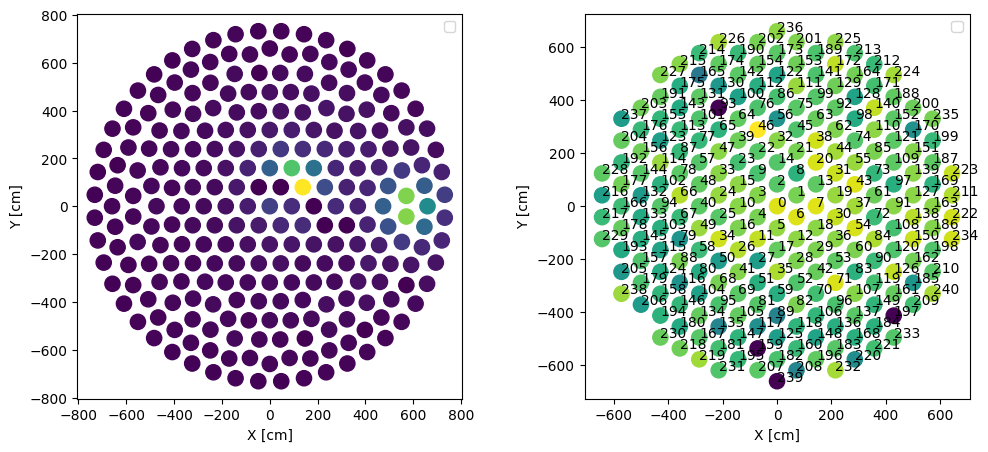

In [6]:
# Plot PMT positions and respective response
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121)
plt.scatter(lceSim.Xtop, lceSim.Ytop, c=s2top, s=120)
ax.set(xlabel="X [cm]", ylabel="Y [cm]")
lgd = plt.legend()
ax.set_box_aspect(1)

ax = fig.add_subplot(122)
plt.scatter(lceSim.Xbot, lceSim.Ybot, c=s2bot, s=120)

i=0
for ix, iy in zip(lceSim.Xbot, lceSim.Ybot):
    plt.annotate(str(i), (ix, iy), fontsize=10)
    i+=1

ax.set(xlabel="X [cm]", ylabel="Y [cm]")
lgd = plt.legend()
ax.set_box_aspect(1)

## Simulate N double scatter events

In [5]:
# Generate double scatter event
def generate_random_coordinates(max_radius=680):
    # Generate the first point within the maximum radial distance
    r1 = np.random.uniform(0, max_radius**2)**0.5
    theta1 = np.random.uniform(0, 2 * np.pi)
    x1 = r1 * np.cos(theta1)
    y1 = r1 * np.sin(theta1)
    
    distance = np.random.uniform(2, 100)
    while True:
        # Random angle for the second point
        angle = np.random.uniform(0, 2 * np.pi)
        x2 = x1 + distance * np.cos(angle)
        y2 = y1 + distance * np.sin(angle)

        # Ensure the second point is within the maximum radial distance
        r2 = np.sqrt(x2**2 + y2**2)
        if r2 <= max_radius:
            break

    return [x1, x2], [y1, y2], np.hypot(x1-x2, y1-y2)

## Single Scatters at E = 2.45 MeV

In [12]:
# Generate dataset with PMT response of double scatters
N = 5000
energy = 2458 #kev
evts = [generate_random_coordinates() for i in range(N)]
asym = np.random.uniform(-0.5, 0.5, size=N)

# Convert asymmetry -> fractional ratio pairs, one pair per event
# r1 = (1 + asym) / 2
# r2 = (1 - asym) / 2

dists = []
xs, ys = [], []
s2topDset, s2botDset = [], []
areaBot_s2 = []

for i, evt in enumerate(evts):
    xt, yt, d = evt
    # ratio = np.array([r1[i], r2[i]])
    ''' Create a single scatter using a ratio of 1.0 and 0.0 '''
    s2top, s2bot = lceSim.simScatter(xt, yt, energy, ratio=np.array([1.0, 0.0]))

    s2topDset.append(s2top)
    s2botDset.append(s2bot)

    xs.append(xt)
    ys.append(yt)
    dists.append(d)

    areaBot_s2.append(s2bot.sum())
    
dists = np.array(dists)
xs = np.array(xs)
ys = np.array(ys)

s2topDset = np.array(s2topDset)
s2botDset = np.array(s2botDset)

areaBot_s2 = np.array(areaBot_s2)

# s2_asym = (areaBot_s2a - areaBot_s2b) / (areaBot_s2a + areaBot_s2b)

### Check some evts

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


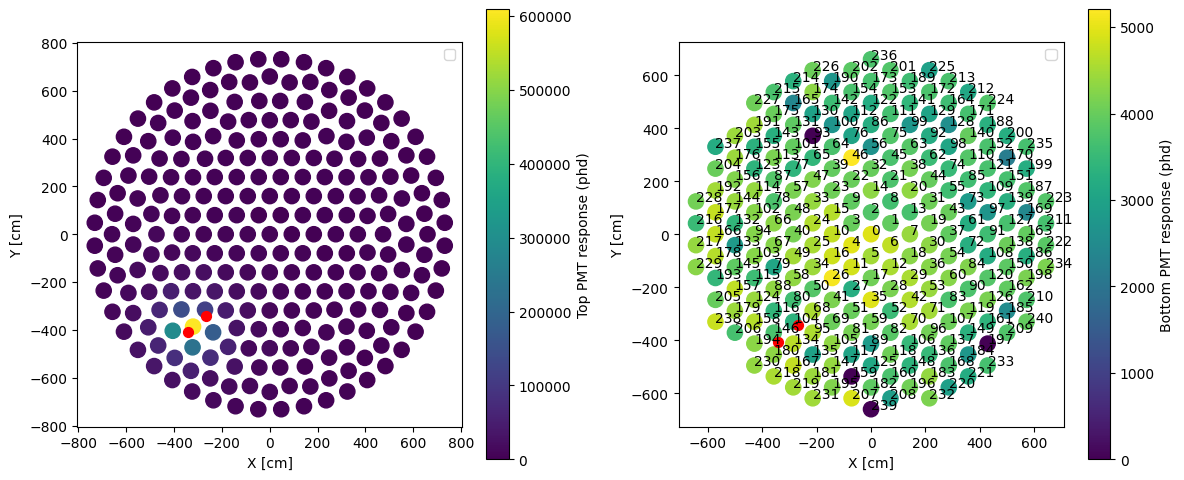

In [13]:
#Check some events
mask = (np.array(dists) > 90)
evtid = np.where(mask)[0][5]

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121)
scat = ax.scatter(lceSim.Xtop, lceSim.Ytop, c=s2topDset[evtid], s=120)
cbar = plt.colorbar(scat, ax=ax)
cbar.set_label('Top PMT response (phd)')
plt.scatter(evts[evtid][0][0], evts[evtid][1][0], s=50, c="r")
plt.scatter(evts[evtid][0][1], evts[evtid][1][1], s=50, c="r")

# print(f"S2top: {s2topDset[evtid]}")
# print(f"S2bot: {s2botDset[evtid]}")

ax.set(xlabel="X [cm]", ylabel="Y [cm]")
lgd = plt.legend()
ax.set_box_aspect(1)

ax = fig.add_subplot(122)
scat = ax.scatter(lceSim.Xbot, lceSim.Ybot, c=s2botDset[evtid], s=120)
cbar = plt.colorbar(scat, ax=ax)
cbar.set_label('Bottom PMT response (phd)')
plt.scatter(evts[evtid][0][0], evts[evtid][1][0], s=50, c="r")
plt.scatter(evts[evtid][0][1], evts[evtid][1][1], s=50, c="r")

i=0
for ix, iy in zip(lceSim.Xbot, lceSim.Ybot):
    plt.annotate(str(i), (ix, iy), fontsize=10)
    i+=1

ax.set(xlabel="X [cm]", ylabel="Y [cm]")
lgd = plt.legend()
ax.set_box_aspect(1)

plt.tight_layout()

### Apply saturation curves to top array

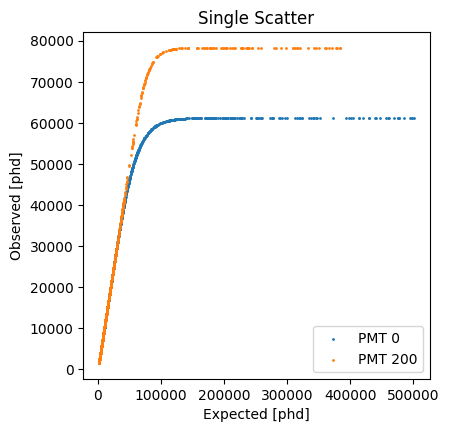

In [14]:
# Apply saturation to top array and plot Observed vs expected
s2topDset_sat = lceSim.applyPMTResponseCurve(s2topDset)

fig = plt.figure(figsize=(12, 7))

ax = fig.add_subplot(131)
for ip in [0, 200]:
    ax.scatter(s2topDset[:,ip], s2topDset_sat[:,ip], s=1, label=f'PMT {ip}')

ax.set(xlabel="Expected [phd]", ylabel="Observed [phd]")
ax.set_title("Single Scatter")
ax.set_box_aspect(1)
ax.legend()

# ax = fig.add_subplot(133)
# for ip in [0, 200]:
#     ax.scatter(s2topDset[:,ip], s2topDset_sat[:,ip], s=1, label=f'PMT {ip}')

# ax.set(xlabel="Expected [phd]", ylabel="Observed [phd]")
# ax.set_title("Combined MS")
# ax.set_box_aspect(1)
# ax.legend()

plt.tight_layout()
plt.show()

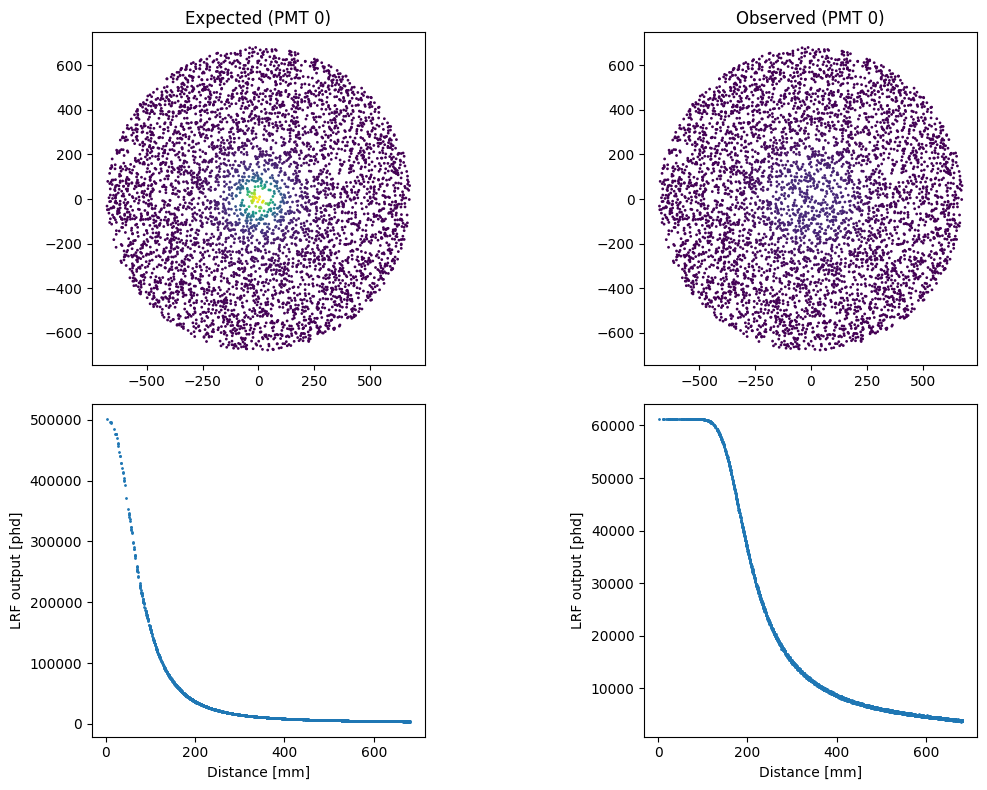

In [15]:
# Evalute each PMT response for all events

ip=0
exp = s2topDset[:,ip] # Expected response
obs = s2topDset_sat[:,ip] # Observed signal (with saturation)

xxs, yys = [], []

# PMT position
xi, yi = lceSim.getModel().getTopLRF().GetX(ip), lceSim.getModel().getTopLRF().GetY(ip)

distance = []
for evt in evts:
    xt, yt, d = evt
    xxs.append(xt[0])
    yys.append(yt[0])
    dd = np.hypot(xt[0]-xi, yt[0]-yi)
    distance.append(dd)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(221)
ax.set_title(f"Expected (PMT {ip})")
plt.scatter(xxs, yys, c=exp, s=1, vmax=exp.max())
ax.set_box_aspect(1)

ax = fig.add_subplot(222)
ax.set_title(f"Observed (PMT {ip})")
plt.scatter(xxs, yys, c=obs, s=1, vmax=exp.max())
ax.set_box_aspect(1)

ax = fig.add_subplot(223)
plt.scatter(distance, exp,s=1)
ax.set(xlabel="Distance [mm]", ylabel="LRF output [phd]")
ax.set_box_aspect(1)

ax = fig.add_subplot(224)
plt.scatter(distance, obs,s=1)
ax.set(xlabel="Distance [mm]", ylabel="LRF output [phd]")
ax.set_box_aspect(1)

fig.tight_layout()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


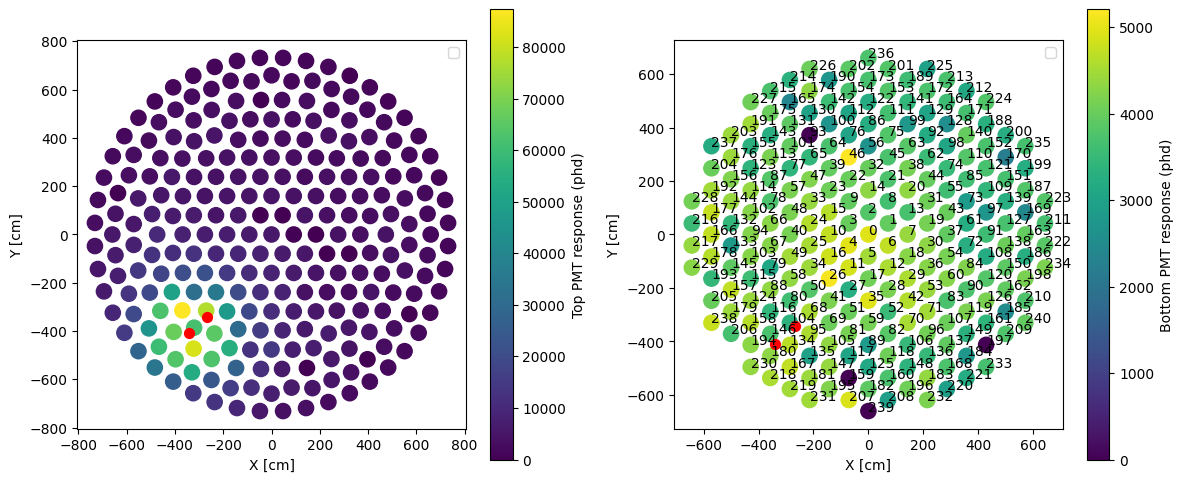

In [16]:
#Check some events
mask = (np.array(dists) > 90)
evtid = np.where(mask)[0][5]

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121)
scat = ax.scatter(lceSim.Xtop, lceSim.Ytop, c=s2topDset_sat[evtid], s=120)
cbar = plt.colorbar(scat, ax=ax)
cbar.set_label('Top PMT response (phd)')
plt.scatter(evts[evtid][0][0], evts[evtid][1][0], s=50, c="r")
plt.scatter(evts[evtid][0][1], evts[evtid][1][1], s=50, c="r")

# print(f"S2top: {s2topDset[evtid]}")
# print(f"S2bot: {s2botDset[evtid]}")

ax.set(xlabel="X [cm]", ylabel="Y [cm]")
lgd = plt.legend()
ax.set_box_aspect(1)

ax = fig.add_subplot(122)
scat = ax.scatter(lceSim.Xbot, lceSim.Ybot, c=s2botDset[evtid], s=120)
cbar = plt.colorbar(scat, ax=ax)
cbar.set_label('Bottom PMT response (phd)')
plt.scatter(evts[evtid][0][0], evts[evtid][1][0], s=50, c="r")
plt.scatter(evts[evtid][0][1], evts[evtid][1][1], s=50, c="r")

i=0
for ix, iy in zip(lceSim.Xbot, lceSim.Ybot):
    plt.annotate(str(i), (ix, iy), fontsize=10)
    i+=1

ax.set(xlabel="X [cm]", ylabel="Y [cm]")
lgd = plt.legend()
ax.set_box_aspect(1)

plt.tight_layout()

### Measure Mercury's $\chi^2$ dependency

In [17]:
#Initialize mercury with the same LRFs as from the simulator
mercury = pywrapper_mercury.PyMercury()
mercury.setTopLRF(lceSim.getModel().getTopLRF())
mercury.makeMercury()

mercury1 = pywrapper_mercury.PyMercury()
mercury1.setTopLRF(lceSim.getModel().getTopLRF())
mercury1.makeMercury()

s2topDset_sat = lceSim.applyPMTResponseCurve(s2topDset)

# Recosntruct with and without saturation simulation
mercury.reconstruct(s2topDset_sat)
SSresults_sat = mercury.getResults()

mercury1.reconstruct(s2topDset)
SSresults_nosat = mercury1.getResults()

5000 4991


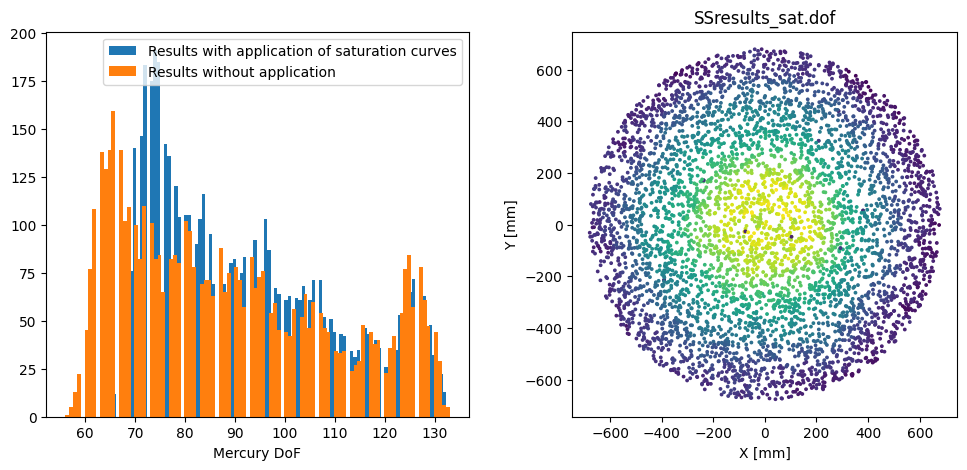

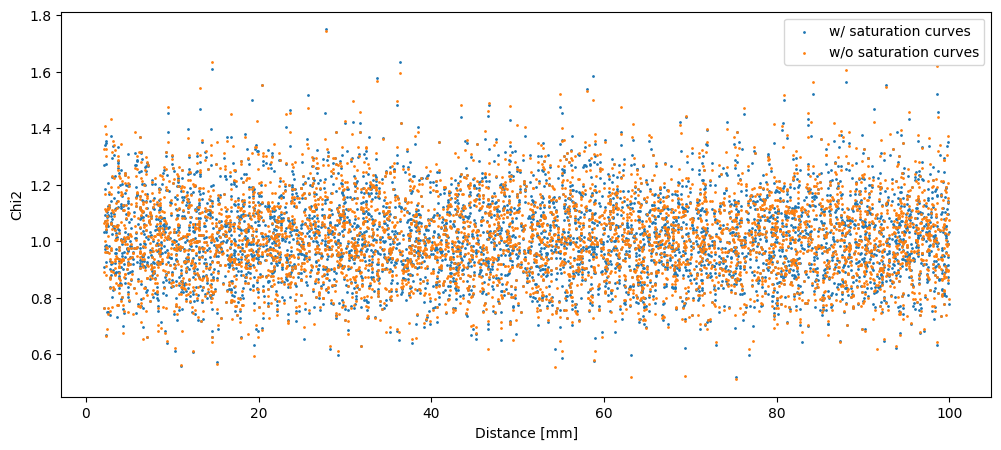

In [18]:
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(121)

ax.hist(SSresults_sat.dof, bins=100, label='Results with application of saturation curves')
ax.hist(SSresults_nosat.dof, bins=100, label='Results without application')
ax.set_xlabel("Mercury DoF")
ax.legend()

ax = fig.add_subplot(122)

ax.scatter(SSresults_sat.x, SSresults_sat.y, c=SSresults_sat.dof, s=3)

ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_title('SSresults_sat.dof')
ax.set_box_aspect(1)

cc = (SSresults_sat.chi2 < 100)
cc1 =  (SSresults_nosat.chi2 < 100)
print(len(SSresults_sat.chi2), cc.sum())

fig = plt.figure(figsize=(12, 5))
plt.scatter(dists[cc], SSresults_sat.chi2[cc], s=1, label='w/ saturation curves')
plt.scatter(dists[cc1], SSresults_nosat.chi2[cc1], s=1, label='w/o saturation curves')
fig.axes[0].set(xlabel="Distance [mm]", ylabel="Chi2")
fig.axes[0].legend()

In [19]:
data = {
    'dists': dists,
    'xs': xs,
    'ys': ys,
    's2topDset': s2topDset_sat,
    's2botDset': s2botDset,
    'areaBot_s2': areaBot_s2,
    'chi2': SSresults_sat.chi2,
    'E': SSresults_sat.e
}

with open('lceSim_SingleScatters.pkl', "wb") as file:
    pickle.dump(data, file)

## Double Scatters at E = 2.45 MeV

In [22]:
# Generate dataset with PMT response of double scatters
N = 5000
energy = 2458 #kev

# Define slices in terms of the majority share percentage (r1 as %)
# split_values = [50, 60, 70, 80, 90]
split_values = np.arange(50, 100, 1)


# # Convert each range to corresponding asym range
# # r1 = (1+asym)/2  =>  asym = 2*r1 - 1
# asym_bins = [(2*(lo/100) - 1, 2*(hi/100) - 1) for lo, hi in split_bins]

#Initialize mercury with the same LRFs as from the simulator
mercury = pywrapper_mercury.PyMercury()
mercury.setTopLRF(lceSim.getModel().getTopLRF())
mercury.makeMercury()

results = {}
for split_pct in split_values:
    print(f"Running reconstruction for {split_pct}% split...")

    xx, yy = [], []
    dists  = []
    chi2s  = []
    xs_reco, ys_reco = [], []

    areaBot_s2sum = []
    s2topDset = []
    s2botDset = []

    r1 = split_pct / 100
    r2 = 1 - r1
    ratio = np.array([r1, r2]) # Same ratio for every event

    for i in range(N):
        xt, yt, d = generate_random_coordinates()

        """ Produce a double scatter with ratio of r1 and r2 """
        s2top, s2bot = lceSim.simScatter(xt, yt, energy, ratio=ratio)

        s2topDset.append(s2top)
        s2botDset.append(s2bot)

        xx.append(xt)
        yy.append(yt)
        dists.append(d)

        areaBot_s2sum.append(s2bot.sum())

    # Apply saturation to top array 
    s2topDset_sat = lceSim.applyPMTResponseCurve(np.array(s2topDset))

    # Reconstruct with and without saturation simulation
    mercury.reconstruct(s2topDset_sat)
    mercury_reco = mercury.getResults()

    chi2s.append(mercury_reco.chi2)
    xs_reco.append(mercury_reco.x)
    ys_reco.append(mercury_reco.y)

    results[f'{split_pct}%'] = {
        'xs': np.array(xx), # (N, 2) array of x coordinates for each event
        'ys': np.array(yy), # (N, 2) array of y coordinates for each event
        's2topDset': np.array(s2topDset_sat), # (N, 248) array of top PMT responses for each event
        's2botDset': np.array(s2botDset), # (N, 121) array of bottom PMT responses for each event
        'dist': np.array(dists).flatten(), # (N,) array of distances between the two scatters for each event
        'chi2': np.array(chi2s).flatten(), # (N,) array of chi2 values for each event
        'xs_reco': np.array(xs_reco).flatten(), # (N,) array of reconstructed x coordinates for each event
        'ys_reco': np.array(ys_reco).flatten(), # (N,) array of reconstructed y coordinates for each event
        'areaBot_s2sum': np.array(areaBot_s2sum).flatten() # (N,) array of total bottom PMT response for each event
    }

Running reconstruction for 50% split...
Running reconstruction for 51% split...
Running reconstruction for 52% split...
Running reconstruction for 53% split...
Running reconstruction for 54% split...
Running reconstruction for 55% split...
Running reconstruction for 56% split...
Running reconstruction for 57% split...
Running reconstruction for 58% split...
Running reconstruction for 59% split...
Running reconstruction for 60% split...
Running reconstruction for 61% split...
Running reconstruction for 62% split...
Running reconstruction for 63% split...
Running reconstruction for 64% split...
Running reconstruction for 65% split...
Running reconstruction for 66% split...
Running reconstruction for 67% split...
Running reconstruction for 68% split...
Running reconstruction for 69% split...
Running reconstruction for 70% split...
Running reconstruction for 71% split...
Running reconstruction for 72% split...
Running reconstruction for 73% split...
Running reconstruction for 74% split...


In [ ]:
for split_pct in np.arange(50, 100, 1):
    asym_val = split_pct / 100 * 2 - 1
    results[f'{split_pct}%']['asym'] = asym_val * np.ones_like(results[f'{split_pct}%']['dist'])

with open('results.pkl', 'wb') as f:
    pickle.dump(results, f)

In [5]:
with open('results.pkl', 'rb') as file:
    results = pickle.load(file)

with open('lceSim_SingleScatters.pkl', "rb") as file:
    data = pickle.load(file)

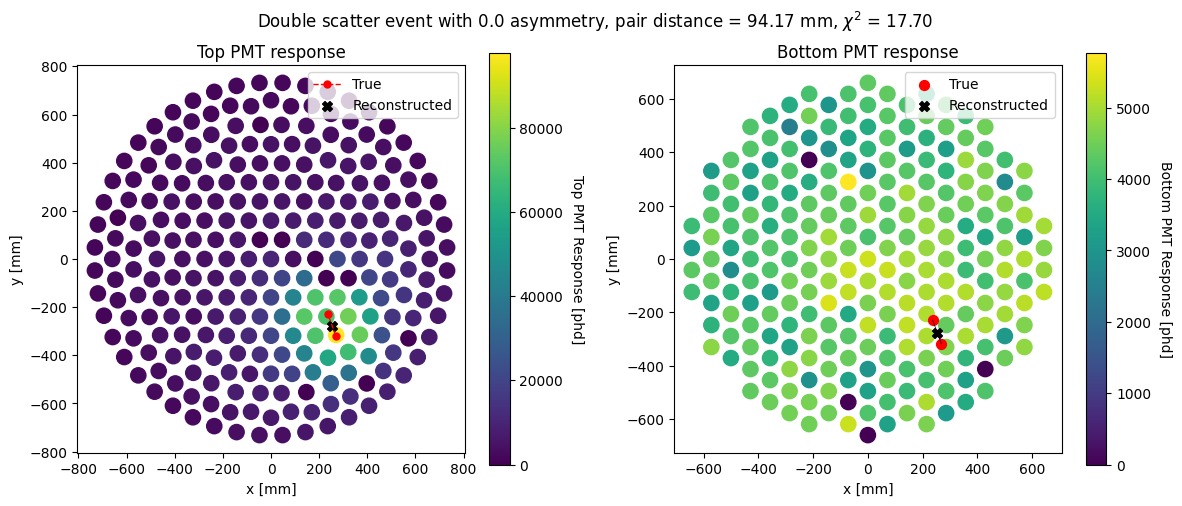

In [6]:
#Check some events
split_pct = 50
mask = (results[f'{split_pct}%']['dist'] > 90) & (results[f'{split_pct}%']['chi2'] < 50)
evtid = np.where(mask)[0][3]  # Get the first event that satisfies the mask

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121)
scat = ax.scatter(lceSim.Xtop, lceSim.Ytop, 
                  c=results[f'{split_pct}%']['s2topDset'][evtid], s=120)#, norm=LogNorm())
cbar = plt.colorbar(scat, ax=ax)
cbar.set_label('Top PMT Response [phd]', rotation=270, labelpad=15)

# ax.scatter(results[f'{split_pct}%']['xs'][evtid], results[f'{split_pct}%']['ys'][evtid], s=50, c="r", label="True")
xs = results[f'{split_pct}%']['xs']
ys = results[f'{split_pct}%']['ys']
ax.plot([xs[evtid][0], xs[evtid][1]], [ys[evtid][0], ys[evtid][1]], ls='--', linewidth=1, color='red', markeredgecolor='red', marker='o', markersize=5, label="True")
ax.scatter(results[f'{split_pct}%']['xs_reco'][evtid], results[f'{split_pct}%']['ys_reco'][evtid], s=50, c="black", marker="X", label="Reconstructed")

ax.set(xlabel="x [mm]", ylabel="y [mm]")
lgd = plt.legend()
ax.set_box_aspect(1)
ax.set_title(f"Top PMT response") 

ax = fig.add_subplot(122)
scat = ax.scatter(lceSim.Xbot, lceSim.Ybot, c=results[f'{split_pct}%']['s2botDset'][evtid], s=120)#, norm=LogNorm())
cbar = plt.colorbar(scat, ax=ax)
cbar.set_label('Bottom PMT Response [phd]', rotation=270, labelpad=15)

ax.scatter(results[f'{split_pct}%']['xs'][evtid], results[f'{split_pct}%']['ys'][evtid], s=50, c="r", label="True")
xs = results[f'{split_pct}%']['xs']
ys = results[f'{split_pct}%']['ys']
ax.plot([xs[evtid][0], xs[evtid][1]], [ys[evtid][0], ys[evtid][1]], linewidth=0.5, color='black')
ax.scatter(results[f'{split_pct}%']['xs_reco'][evtid], results[f'{split_pct}%']['ys_reco'][evtid], s=50, c="black", marker="X", label="Reconstructed")

# i=0
# for ix, iy in zip(lceSim.Xbot, lceSim.Ybot):
#     plt.annotate(str(i), (ix, iy), fontsize=10)
#     i+=1

ax.set(xlabel="x [mm]", ylabel="y [mm]")
lgd = plt.legend()
ax.set_box_aspect(1)
ax.set_title(f"Bottom PMT response")

plt.suptitle(fr"Double scatter event with {(split_pct/100 *2 -1):.1f} asymmetry, pair distance = {results[f'{split_pct}%']['dist'][evtid]:.2f} mm, $\chi^2$ = {results[f'{split_pct}%']['chi2'][evtid]:.2f}")
plt.tight_layout()

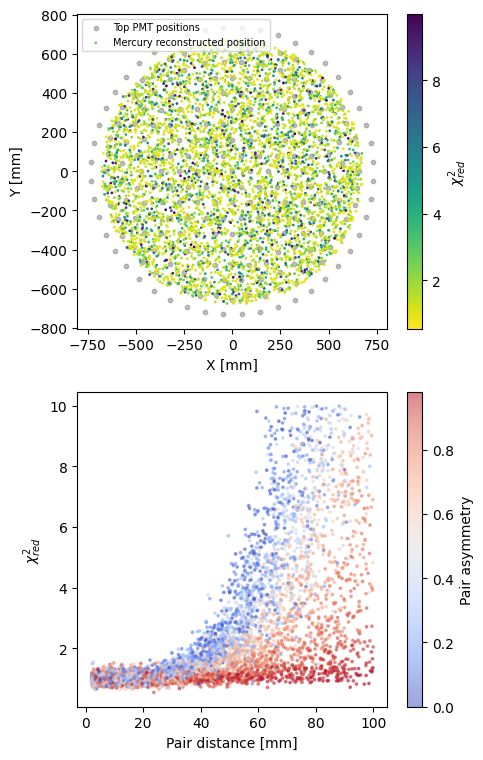

In [ ]:
fig = plt.figure(figsize=(5, 9))
ax = fig.add_subplot(212)

dists = np.concatenate([
    results[f'{asym}%']['dist'][results[f'{asym}%']['chi2'] < 10]
    for asym in np.arange(50, 100, 1)
])
chi2s = np.concatenate([
    results[f'{asym}%']['chi2'][results[f'{asym}%']['chi2'] < 10]
    for asym in np.arange(50, 100, 1)
])
asym = np.concatenate([
    results[f'{asym}%']['asym'][results[f'{asym}%']['chi2'] < 10]
    for asym in np.arange(50, 100, 1)
])

mask = asym <= 1

n_sample = 5000
n_total  = mask.sum()

if n_total > n_sample:
    idx = np.random.choice(n_total, size=n_sample, replace=False)
else:
    idx = np.arange(n_total)  

scat = ax.scatter(dists[mask][idx], chi2s[mask][idx], s=3, alpha=0.5,
                  c=asym[mask][idx], cmap='coolwarm')
cbar = plt.colorbar(scat, ax=ax)
cbar.set_label('Pair asymmetry')
ax.set(xlabel="Pair distance [mm]", ylabel=r"$\chi^2_{red}$")
# ax.legend()

ax = fig.add_subplot(211)
xs_reco = np.concatenate([
    results[f'{asym}%']['xs_reco'][results[f'{asym}%']['chi2'] < 10]
    for asym in np.arange(50, 100, 1)
])
ys_reco = np.concatenate([
    results[f'{asym}%']['ys_reco'][results[f'{asym}%']['chi2'] < 10]
    for asym in np.arange(50, 100, 1)
])
ax.scatter(lceSim.Xtop, lceSim.Ytop, s=10, marker='o', alpha=0.5, label='Top PMT positions', c='gray')
scat = ax.scatter(xs_reco[idx], ys_reco[idx], s=1,
                  c=chi2s[idx], cmap='viridis_r', label='Mercury reconstructed position')
cbar = plt.colorbar(scat, ax=ax)
cbar.set_label(r"$\chi^2_{red}$")
ax.set(xlabel="X [mm]", ylabel="Y [mm]")
ax.legend(fontsize=7, loc='upper left')

In [17]:
# plt.scatter(asym, s2_asym, s=5, alpha=0.4)
# plt.xlabel('Injected asymmetry')
# plt.ylabel('Measured s2_asym (from output areas)')
# plt.plot([-0.5,0.5],[-0.5,0.5], color='red', ls='--')
# # plt.legend()

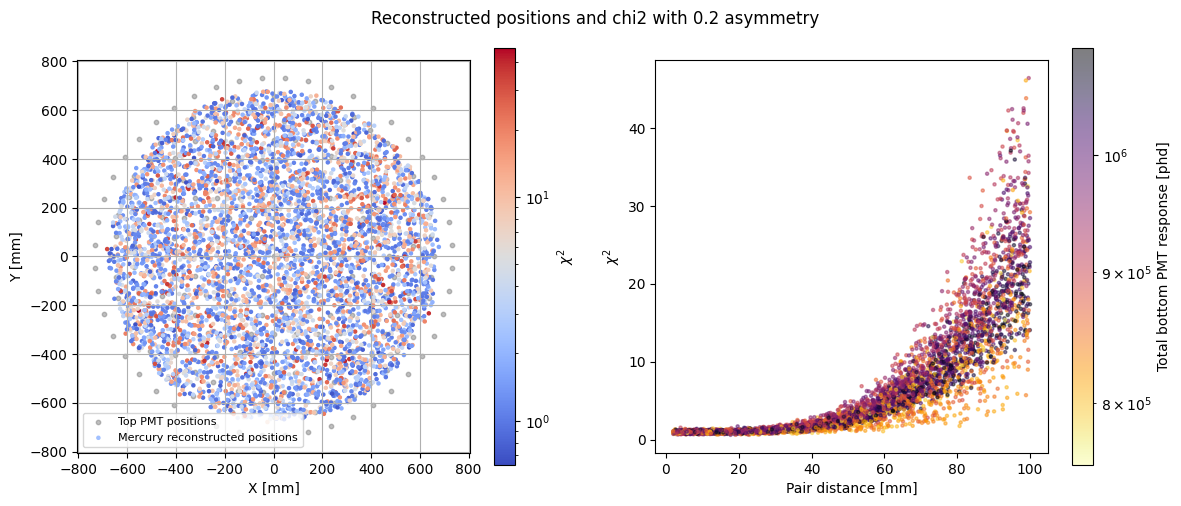

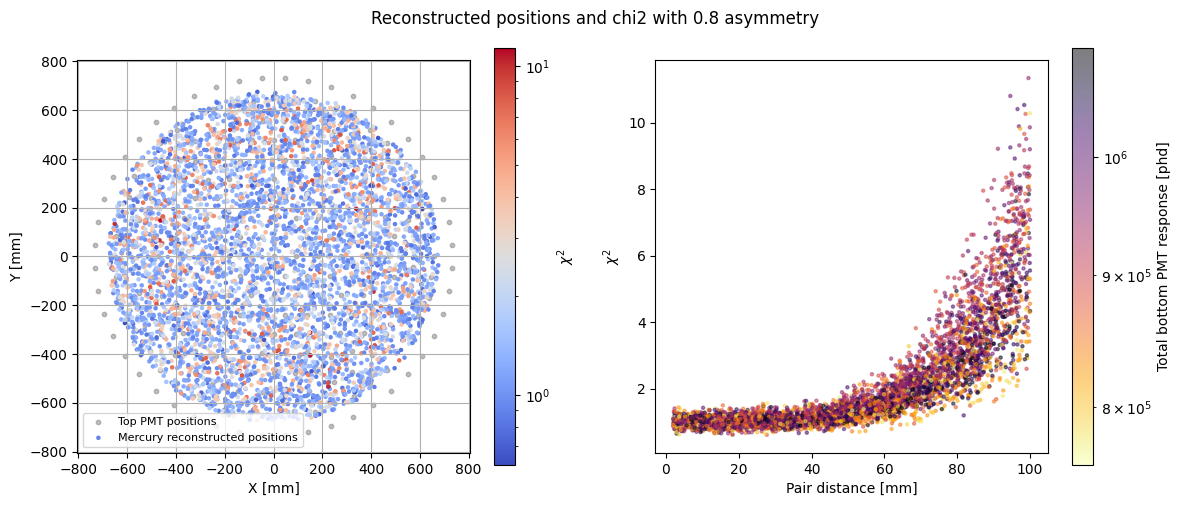

In [24]:
for split_pct in [60, 90]:
    fig = plt.figure(figsize=(12, 5))
    cc = (results[f'{split_pct}%']['chi2'] < 100)

    ax = fig.add_subplot(121)
    ax.set_box_aspect(1)
    ax.scatter(lceSim.Xtop, lceSim.Ytop, s=10, marker='o', alpha=0.5, label='Top PMT positions', c='gray')
    scat1 = ax.scatter(results[f'{split_pct}%']['xs_reco'][cc], results[f'{split_pct}%']['ys_reco'][cc], s=5, 
                    c=results[f'{split_pct}%']['chi2'][cc], cmap='coolwarm', label='Mercury reconstructed positions', norm=LogNorm())
    cbar = plt.colorbar(scat1, ax=ax)
    cbar.set_label(r'$\chi^2$')
    ax.set(xlabel="X [mm]", ylabel="Y [mm]")
    ax.grid()
    ax.legend(fontsize=8)
    
    ax = fig.add_subplot(122)
    ax.set_box_aspect(1)
    scat2 = ax.scatter(results[f'{split_pct}%']['dist'][cc], results[f'{split_pct}%']['chi2'][cc], s=5, alpha=0.5, 
                        c=results[f'{split_pct}%']['areaBot_s2sum'][cc], cmap='inferno_r', norm=LogNorm())
    cbar = plt.colorbar(scat2, ax=ax)
    cbar.set_label('Total bottom PMT response [phd]')
    ax.set(xlabel="Pair distance [mm]", ylabel=r"$\chi^2$")

    plt.suptitle(f"Reconstructed positions and chi2 with {(split_pct/100 *2 -1):.1f} asymmetry")
    plt.tight_layout()

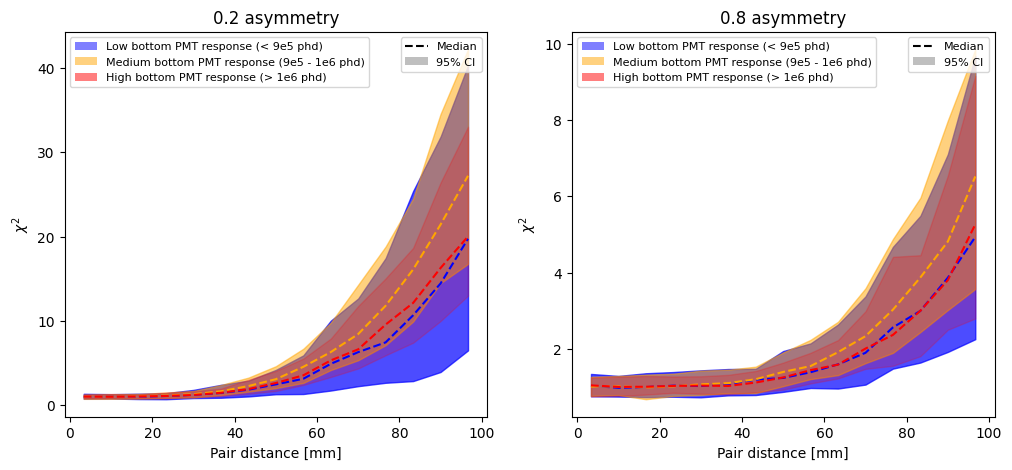

In [25]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for split_pct, ax in zip([60, 90], axes):
    cc = (results[f'{split_pct}%']['chi2'] < 100)
    mask_low  = (results[f'{split_pct}%']['areaBot_s2sum'] < 9e5) & cc
    mask_med  = (results[f'{split_pct}%']['areaBot_s2sum'] >= 9e5) & (results[f'{split_pct}%']['areaBot_s2sum'] < 1e6) & cc
    mask_high = (results[f'{split_pct}%']['areaBot_s2sum'] >= 1e6) & cc

    # ax.scatter(results[f'{split_pct}%']['dist'][mask_low], results[f'{split_pct}%']['chi2'][mask_low], s=5, alpha=0.7, label='Low bottom PMT response', c='blue')
    # ax.scatter(results[f'{split_pct}%']['dist'][mask_med], results[f'{split_pct}%']['chi2'][mask_med], s=5, alpha=0.5, label='Medium bottom PMT response', c='orange')
    # ax.scatter(results[f'{split_pct}%']['dist'][mask_high], results[f'{split_pct}%']['chi2'][mask_high], s=5, alpha=0.2, label='High bottom PMT response', c='red')

    dist_bins = np.linspace(0, 100, 16)
    bin_centers = 0.5 * (dist_bins[1:] + dist_bins[:-1])
    chi2_percentiles = {'low':
                        {'2.5': [], '50': [], '97.5': []},
                        'med':
                        {'2.5': [], '50': [], '97.5': []},
                        'high':
                        {'2.5': [], '50': [], '97.5': []}
                        }

    for mask, label in zip([mask_low, mask_med, mask_high], ['low', 'med', 'high']):
        chi2s = results[f'{split_pct}%']['chi2'][mask]
        dists = results[f'{split_pct}%']['dist'][mask]

        for i in range(len(dist_bins)-1):
            bin_mask = (dists >= dist_bins[i]) & (dists < dist_bins[i+1])
            chi2s_in_bin = chi2s[bin_mask]

            if len(chi2s_in_bin) > 0:
                p_2_5  = np.percentile(chi2s_in_bin, 2.5)
                p_50   = np.percentile(chi2s_in_bin, 50)
                p_97_5 = np.percentile(chi2s_in_bin, 97.5)

                chi2_percentiles[label]['2.5'].append(p_2_5)
                chi2_percentiles[label]['50'].append(p_50)
                chi2_percentiles[label]['97.5'].append(p_97_5)

    for label, color, alpha in zip(['low', 'med', 'high'], ['blue', 'orange', 'red'], [0.7, 0.5, 0.2]):
        ax.plot(bin_centers, chi2_percentiles[label]['50'], ls='--', label=f'Median ({label} bottom PMT response)', color=color)
        ax.fill_between(bin_centers, chi2_percentiles[label]['2.5'], chi2_percentiles[label]['97.5'], alpha=alpha, label=f'95% CI', color=color)

    ax.set(xlabel="Pair distance [mm]", ylabel=r"$\chi^2$")
    ax.set_title(f"{(split_pct/100 *2 -1):.1f} asymmetry")
    # ax.legend(fontsize=5, loc='upper left')

    style_handles = [
        Line2D([0], [0], color='black', ls='--', label='Median'),
        Patch(facecolor='gray', alpha=0.5, label='95% CI')
    ]

    color_handles = [
        Patch(facecolor='blue', alpha=0.5, label='Low bottom PMT response (< 9e5 phd)'),
        Patch(facecolor='orange', alpha=0.5, label='Medium bottom PMT response (9e5 - 1e6 phd)'),
        Patch(facecolor='red', alpha=0.5, label='High bottom PMT response (> 1e6 phd)')
    ]

    legend1 = ax.legend(handles=style_handles, loc='upper right', fontsize=8)
    legend2 = ax.legend(handles=color_handles, loc='upper left', fontsize=8)
    ax.add_artist(legend1)

    # ax.set_ylim(0, 5)

## Preliminary Results Comparison

In [5]:
projenitors_file = '/home/denis/MSXYchopstitch/msxyData_worepl_15cm_customHGLG_20260720_projenitors.pkl'
with open(projenitors_file, "rb") as file:
    projenitors = pickle.load(file)

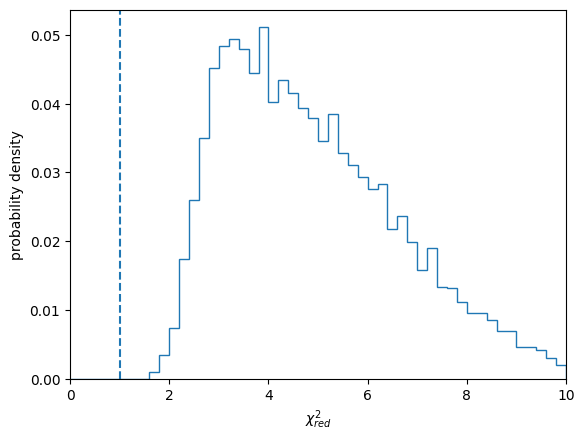

In [11]:
chi2_s2ab = projenitors['chi2'][projenitors['chi2'] < 10]
plt.hist(chi2_s2ab, bins=50, range=(0, 10), histtype='step',
         weights=np.ones_like(chi2_s2ab) / len(chi2_s2ab))
plt.axvline(1, ls='--')
plt.xlim(0, 10)
plt.xlabel(r'$\chi^2_{red}$')
plt.ylabel('probability density')
plt.show()

In [13]:
with open('results.pkl', 'rb') as file:
    results = pickle.load(file)

with open('lceSim_SingleScatters.pkl', "rb") as file:
    data = pickle.load(file)

with open('geant4_double_scatters.pkl', "rb") as file:
    geant4 = pickle.load(file)

7185


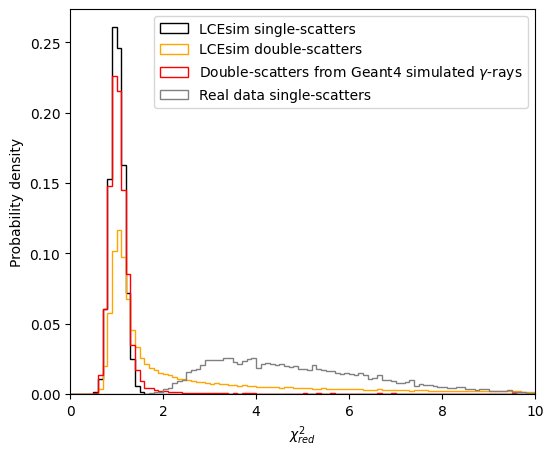

In [ ]:
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

shared_range = (0, 10)
shared_bins  = 100

chi2_values = data['chi2'][data['chi2'] < 10]
ax.hist(chi2_values, bins=shared_bins, range= shared_range, histtype='step', color='black', 
        weights=np.ones_like(chi2_values) / len(chi2_values),
        # density=True,
        label='LCEsim single-scatters')

chi2_total = np.concatenate([
    results[f'{asym}%']['chi2'][results[f'{asym}%']['chi2'] < 10]
    for asym in np.arange(50, 100, 1)
])
ax.hist(chi2_total, bins=shared_bins, range= shared_range, histtype='step', color='orange',
        weights=np.ones_like(chi2_total) / len(chi2_total),
        # density=True,
        label=fr'LCEsim double-scatters') # {asym/100 * 2 -1} asymmetry')

chi_mask = (geant4['chi2'] > 0) & (geant4['chi2'] < 10)
E_mask   = (geant4['pair_energies'].sum(axis=1) > 2.1) & (geant4['pair_energies'].sum(axis=1) < 2.7)
chi2s = geant4['chi2'][chi_mask & E_mask]
print(len(chi2s))
 
ax.hist(chi2s, bins=shared_bins, range= shared_range, histtype='step', color='red',
        weights=np.ones_like(chi2s) / len(chi2s),
        # density=True,
        label=r'Double-scatters from Geant4 simulated $\gamma$-rays')

chi2_s2ab = projenitors['chi2'][projenitors['chi2'] < 10]
ax.hist(chi2_s2ab, bins=shared_bins, range= shared_range, histtype='step', color='gray', 
        weights=np.ones_like(chi2_s2ab) / len(chi2_s2ab),
        # density=True,
        label='Real data single-scatters')

ax.set_xlabel(r'$\chi^2_{red}$')
ax.set_ylabel('Probability density')
ax.set_xlim(0, 10)
ax.legend()

plt.show()


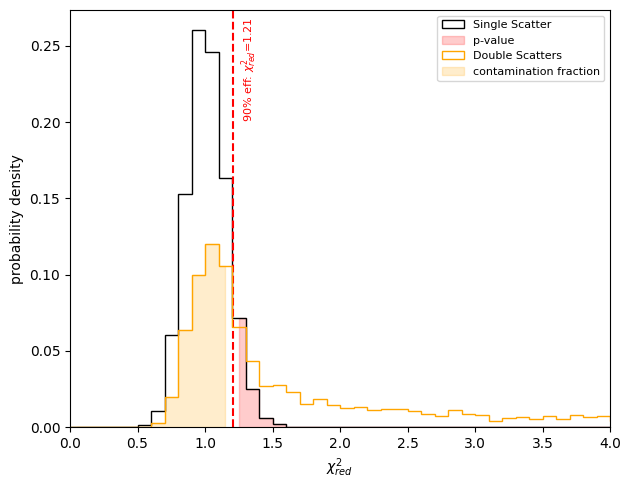

In [ ]:
fig = plt.figure(figsize=(18,5))
ax = fig.add_subplot(132)

chi2_values = data['chi2'][data['chi2'] < 10]
ax.hist(chi2_values, bins=100, range=(0,10), histtype='step', color='black', label='Single Scatter', weights=np.ones_like(chi2_values) / len(chi2_values))

counts, bin_edges = np.histogram(chi2_values, bins=100, range=(0,10), weights=np.ones_like(chi2_values) / len(chi2_values))
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

colors = ['red']
for pct, color in zip([90], colors):
    cut = np.percentile(chi2_values, pct)
    ax.axvline(cut, color=color, ls='--') #, label=fr'{pct}% eff. cut: $ \chi^2 = {cut:.2f} $')
    ax.text(cut +0.05, 0.2, fr'{pct}% eff: $\chi^2_{{red}}$={cut:.2f}', color=color, fontsize=8, ha='left', va='bottom', rotation=90)

    mask = bin_centers > cut
    p_value = np.mean(chi2_values > cut)
    ax.fill_between(bin_centers[mask], 0, counts[mask], color=color, alpha=0.2, step='mid', label='p-value')
dists = np.concatenate([
    results[f'{asym}%']['dist'][results[f'{asym}%']['chi2'] < 10]
    for asym in np.arange(50, 100, 1)
])
chi2s = np.concatenate([
    results[f'{asym}%']['chi2'][results[f'{asym}%']['chi2'] < 10]
    for asym in np.arange(50, 100, 1)
])
asym = np.concatenate([
    results[f'{asym}%']['asym'][results[f'{asym}%']['chi2'] < 10]
    for asym in np.arange(50, 100, 1)
])
mask = asym < 1
n_sample = 5000
n_total  = mask.sum()

if n_total > n_sample:
    idx = np.random.choice(n_total, size=n_sample, replace=False)
else:
    idx = np.arange(n_total)

ax.hist(chi2s[idx], bins=100, range=(0, 10), histtype='step', color='orange', label=fr'Double Scatters', weights=np.ones_like(chi2s[idx]) / len(chi2s[idx]))
counts, bin_edges = np.histogram(chi2s[idx], bins=100, range=(0,10), weights=np.ones_like(chi2s[idx]) / len(chi2s[idx]))
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
mask = bin_centers < cut
ax.fill_between(bin_centers[mask], 0, counts[mask], color='orange', alpha=0.2, step='mid', label='contamination fraction')

ax.set_xlabel(r"$\chi^2_{red}$")
ax.set_ylabel('probability density')
ax.set_xlim(0, 4)
ax.legend(fontsize=8)

plt.tight_layout()

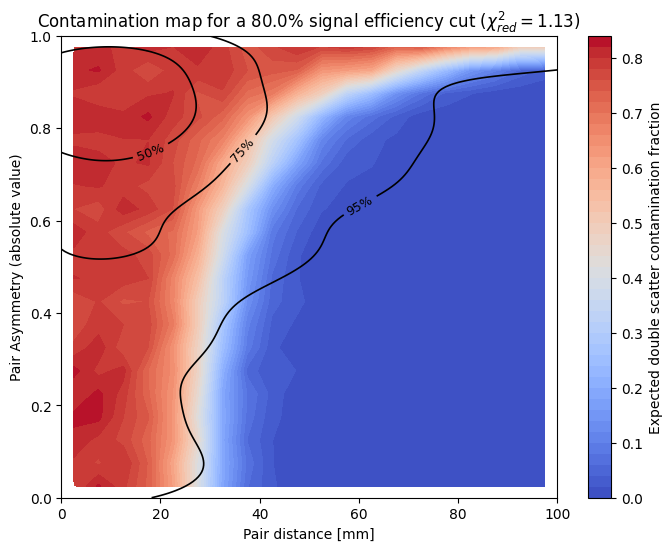

In [19]:
from scipy.stats import binned_statistic_2d

all_distances, all_asymmetry, all_chi2 = [], [], []

chi2_values = data['chi2'][data['chi2'] < 10]

target_eff = 0.8
chi2_cut = np.quantile(chi2_values, target_eff)


for split_pct in np.arange(50, 100, 1):
    cc = (results[f'{split_pct}%']['chi2'] < 10)

    distances = results[f'{split_pct}%']['dist'][cc]
    asymmetry = split_pct / 100 * 2 - 1  # Convert split percentage to asymmetry
    chi2      = results[f'{split_pct}%']['chi2'][cc]

    all_distances.append(distances)
    all_asymmetry.append(asymmetry * np.ones_like(distances))
    all_chi2.append(chi2)

# Concatenate everything to single flat arrays
all_distances = np.concatenate(all_distances)
all_asymmetry = np.concatenate(all_asymmetry)
all_chi2      = np.concatenate(all_chi2)

dist_bins = np.linspace(0, 100, 21)
asym_bins = np.linspace(0, 1, 21)

contamination_map, x_edge, y_edge, _ = binned_statistic_2d(
    all_distances, all_asymmetry, all_chi2, 
    statistic=lambda x: np.mean(x < chi2_cut), 
    bins=[dist_bins, asym_bins]
)

x_centers = 0.5 * (x_edge[1:] + x_edge[:-1])
y_centers = 0.5 * (y_edge[1:] + y_edge[:-1])
X, Y = np.meshgrid(x_centers, y_centers)

fig, ax = plt.subplots(figsize=(8, 6))
# levels = np.linspace(0, 50, 51)
cf = ax.contourf(X, Y, contamination_map.T, levels=50, cmap='coolwarm')
plt.colorbar(cf, ax=ax, label='Expected double scatter contamination fraction')

# cut_value = chi2_cut
# cs = ax.contour(X, Y, contamination_map.T, levels=[cut_value], colors='red', linewidths=2)
# ax.clabel(cs, fmt={cut_value: f'${pct}\%$ efficiency $\\chi^2$ = {cut_value:.1f}'})

ax.set_xlabel('Pair distance [mm]')
ax.set_ylabel('Pair Asymmetry (absolute value)')
ax.set_title(fr'Contamination map for a {target_eff*100}% signal efficiency cut ($\chi^2_{{red}}={chi2_cut:.2f}$)')

# --- Overlay: Geant4 population density contour ---
from scipy.stats import gaussian_kde

chi_mask = (geant4['chi2'] > 0) & (geant4['chi2'] < 10)
E_mask   = (geant4['pair_energies'].sum(axis=1) > 2.1) & (geant4['pair_energies'].sum(axis=1) < 2.7)
mask     = chi_mask & E_mask
g4_dist = geant4['distances'][mask]
g4_asym = geant4['asymmetry'][mask]

kde = gaussian_kde(np.vstack([g4_dist, g4_asym]))

grid_dist = np.linspace(0, 100, 200)
grid_asym = np.linspace(0, 1, 200)
Xg, Yg = np.meshgrid(grid_dist, grid_asym)
density = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)

# Evaluate density AT each actual data point, to find percentile thresholds
density_at_points = kde(np.vstack([g4_dist, g4_asym]))

# Find density thresholds corresponding to enclosing 50%, 90% of events
levels = [np.percentile(density_at_points, 100 - p) for p in [95, 75, 50]]  # order matters: ascending density = descending "enclosed %"

cs = ax.contour(Xg, Yg, density, levels=sorted(levels), colors='black', linewidths=1.2)
ax.clabel(cs, fmt={levels[0]: '95%', levels[1]: '75%', levels[2]: '50%'}, inline=True, fontsize=9)

plt.show()

For 60% split: AUC = 0.8462
For 90% split: AUC = 0.7598


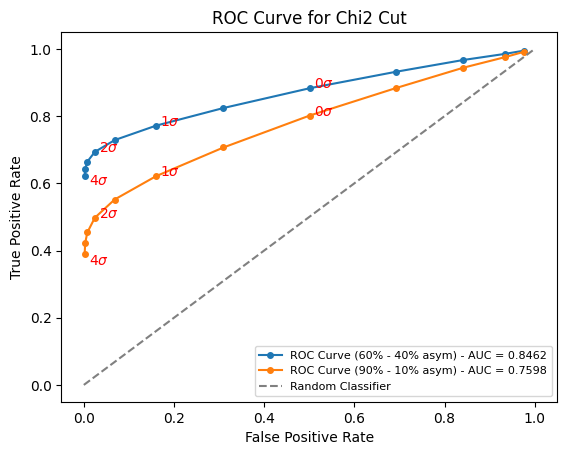

In [21]:
from scipy.stats import norm

sigma_values = np.arange(-2, 4, 0.5)
percentiles  = norm.cdf(sigma_values) * 100 

# print("Percentiles corresponding to sigma values:")
# for sigma, percentile in zip(sigma_values, percentiles):
#     print(f"Sigma: {sigma:.1f}, Percentile: {percentile:.2f}%")

for split_pct in [60, 90]:

    chi2_cut = {}
    FPR, TPR = [], []

    for sigma, pct in zip(sigma_values, percentiles):
        chi2_cut[sigma] = np.percentile(chi2_values, pct)
        # print(f"Sigma: {sigma:.1f}, Chi2 cut: {chi2_cut[sigma]:.2f}")

        FPR.append((SSresults_sat.chi2 > chi2_cut[sigma]).sum() / len(SSresults_sat.chi2))
        TPR.append((results[f'{split_pct}%']['chi2'] > chi2_cut[sigma]).sum() / len(results[f'{split_pct}%']['chi2']))

    FPR = np.array(FPR)
    TPR = np.array(TPR)

    idx = np.argsort(FPR)
    fpr_sorted = FPR[idx]
    tpr_sorted = TPR[idx]
    
    auc = np.trapz(tpr_sorted, fpr_sorted)
    print(f"For {split_pct}% split: AUC = {auc:.4f}")

    plt.plot(FPR, TPR, marker='o', markersize=4, label=f'ROC Curve ({split_pct}% - {100 - split_pct}% asym) - AUC = {auc:.4f}')

    for sigma in [0, 1, 2, 4]:
        pct = norm.cdf(sigma) * 100
        cut = np.percentile(chi2_values, pct)
        fpr_pt = (SSresults_sat.chi2 > cut).sum() / len(SSresults_sat.chi2)
        tpr_pt = (results[f'{split_pct}%']['chi2'] > cut).sum() / len(results[f'{split_pct}%']['chi2'])
    
        plt.annotate(f'${sigma}σ$', xy=(fpr_pt, tpr_pt), xytext=(3, 0), textcoords='offset points', color='red')

plt.plot([0, 1], [0, 1], ls='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Chi2 Cut')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.xscale('log')
# plt.yscale('log')
plt.legend(fontsize=8)
plt.show()

In [1]:
# from scipy.stats import norm

# fig = plt.figure(figsize=(8, 5))
# ax = fig.add_subplot(111)
# ax.set_box_aspect(1)

# sigma_values = np.arange(-2, 4, 0.5)
# percentiles  = norm.cdf(sigma_values) * 100 

# for split_pct, color in zip([60, 90], ['Tab:blue', 'Tab:orange']):
#     chi2_cut = {}
#     FPR, TPR = [], []

#     chi2_singles = data['chi2'][data['chi2'] < 10]
#     chi2_doubles = results[f'{split_pct}%']['chi2'][results[f'{split_pct}%']['chi2'] < 10]

#     all_chi2_values = np.concatenate([chi2_singles, chi2_doubles])
#     thresholds = np.logspace(np.log10(np.min(all_chi2_values)), np.log10(np.max(all_chi2_values)), 100)
    
#     for thresh in thresholds:
#         FPR.append((chi2_doubles < thresh).mean())
#         TPR.append((chi2_singles < thresh).mean())

#     # for sigma, pct in zip(sigma_values, percentiles):
#     #     chi2_cut[sigma] = np.percentile(chi2_values, pct)

#     #     FPR.append((results[f'{split_pct}%']['chi2'] < chi2_cut[sigma]).sum() / len(results[f'{split_pct}%']['chi2']))
#     #     TPR.append((SSresults_sat.chi2 < chi2_cut[sigma]).sum() / len(SSresults_sat.chi2))

#     FPR, TPR = np.array(FPR), np.array(TPR)
    
#     idx = np.argsort(FPR)
#     fpr_sorted = FPR[idx]
#     tpr_sorted = TPR[idx]

#     auc = np.trapz(tpr_sorted, fpr_sorted)
#     print(f"For {split_pct}% split: AUC = {auc:.4f}")

#     ax.plot(FPR, TPR, markersize=4, ls='-', label=fr'ROC Curve ({split_pct}% - {100 - split_pct}% asym) - AUC = {auc:.4f}', color=color)

#     for sigma in [0, 1, 2, 4]:
#         pct = norm.cdf(sigma) * 100
#         cut = np.percentile(chi2_singles, pct)
#         fpr_pt = (results[f'{split_pct}%']['chi2'] < cut).mean()
#         tpr_pt = (data['chi2'] < cut).mean()
#         ax.scatter(fpr_pt, tpr_pt, color=color, s=20)
#         ax.annotate(f'${sigma}σ$', xy=(fpr_pt, tpr_pt), xytext=(1.5, -8), textcoords='offset points', color=color)

# for split_pct, color in zip([60, 90], ['Tab:blue', 'Tab:orange']):
#     chi2_cut = {}
#     FPR, TPR = [], []

#     chi2_singles = data['chi2'][data['chi2'] < 10]
#     chi2_doubles = results[f'{split_pct}%']['chi2'][results[f'{split_pct}%']['chi2'] < 10]

#     all_chi2_values = np.concatenate([chi2_singles, chi2_doubles])
#     thresholds = np.logspace(np.log10(np.min(all_chi2_values)), np.log10(np.max(all_chi2_values)), 100)

#     for thresh in thresholds:
#         FPR.append((chi2_doubles < thresh).mean())
#         TPR.append((chi2_singles < thresh).mean())
#     FPR, TPR = np.array(FPR), np.array(TPR)
#     J = TPR - FPR
#     optimal_idx = np.argmax(J)
#     optimal_threshold = thresholds[optimal_idx]
#     optimal_fpr = FPR[optimal_idx]
#     optimal_tpr = TPR[optimal_idx]
#     ax.scatter(optimal_fpr, optimal_tpr, color=color, s=50, marker='d', label=fr'Optimal $ \chi^2 $ cut: {optimal_threshold:.2f} (FPR={optimal_fpr *100:.2f}%, TPR={optimal_tpr *100:.2f}%)')

#     dist_bins = np.linspace(0, 100, 16)
#     bin_centers = 0.5 * (dist_bins[1:] + dist_bins[:-1])
#     chi2_medians = []
    
#     for i in range(len(dist_bins)-1):
#         mask = (results[f'{split_pct}%']['dist'] > dist_bins[i]) & (results[f'{split_pct}%']['dist'] < dist_bins[i+1])
#         chi2_medians.append(np.median(results[f'{split_pct}%']['chi2'][mask]))
#     medians = np.array(chi2_medians)

#     discriminatory_distance = np.interp(optimal_threshold, medians, bin_centers)
#     print(f"Discriminatory distance for {split_pct}% split: {discriminatory_distance:.2f} mm at optimal chi2 threshold {optimal_threshold:.2f}")

# ax.plot([0, 1], [0, 1], ls='--', color='gray', label='Random Classifier')
# ax.scatter(0, 1, color='green', marker='*', s=100, label='Perfect Classifier')
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title(r'ROC curve for $\chi^2$ Cut')
# ax.legend(fontsize=7)


In [2]:
# import matplotlib.cm as cm
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# axes = axes.flatten()

# for split_pct, ax in zip([60, 90], axes):

#     chi2_singles = SSresults_sat.chi2[SSresults_sat.chi2 < 50]
#     chi2_doubles = results[f'{split_pct}%']['chi2'][results[f'{split_pct}%']['chi2'] < 50]

#     all_chi2_values = np.concatenate([chi2_singles, chi2_doubles])
#     thresholds = np.logspace(np.log10(np.min(all_chi2_values)), np.log10(np.max(all_chi2_values)), 100)

#     distances = results[f'{split_pct}%']['dist'][results[f'{split_pct}%']['chi2'] < 50]
#     dist_ranges = [0, 10, 20, 30, 40, 50, 60]
#     for k, value in enumerate(dist_ranges[:-1]):
#         mask = (distances >= dist_ranges[k]) & (distances < dist_ranges[k + 1])
#         if np.any(mask):
#             chi2_doubles_subset = chi2_doubles[mask]
#             FPR_subset = []
#             TPR_subset = []
#             for thresh in thresholds:
#                 FPR_subset.append((chi2_doubles_subset < thresh).mean())
#                 TPR_subset.append((chi2_singles < thresh).mean())
#             FPR_subset, TPR_subset = np.array(FPR_subset), np.array(TPR_subset)
#             ax.plot(FPR_subset, TPR_subset, label=f'Distance {value}-{dist_ranges[k + 1]} mm', color=cm.plasma_r(k / len(dist_ranges)))
#     ax.plot([0, 1], [0, 1], ls='--', color='gray', label='Random Classifier')
#     ax.scatter(0, 1, color='green', marker='*', s=100, label='Perfect Classifier')
#     ax.set_xlabel('False Positive Rate')
#     ax.set_ylabel('True Positive Rate')
#     ax.set_title(fr'ROC curve for $\chi^2$ Cut ({split_pct}% - {100 - split_pct}% asym)')
#     ax.legend(fontsize=7)

# plt.tight_layout()
    

Discriminatory asymmetry for 0-10 mm pair separation: 0.97 at optimal chi2 threshold 1.32
Discriminatory asymmetry for 10-20 mm pair separation: 0.03 at optimal chi2 threshold 1.03
Discriminatory asymmetry for 20-30 mm pair separation: 0.97 at optimal chi2 threshold 1.06
Discriminatory asymmetry for 30-40 mm pair separation: 0.97 at optimal chi2 threshold 1.13
Discriminatory asymmetry for 40-50 mm pair separation: 0.97 at optimal chi2 threshold 1.28
Discriminatory asymmetry for 50-60 mm pair separation: 0.97 at optimal chi2 threshold 1.32
Discriminatory asymmetry for 60-70 mm pair separation: 0.97 at optimal chi2 threshold 1.36
Discriminatory asymmetry for 70-80 mm pair separation: 0.97 at optimal chi2 threshold 1.36
Discriminatory distance for 0.0-0.1 asymmetry: 36.54 mm at optimal chi2 threshold 1.28
Discriminatory distance for 0.1-0.5 asymmetry: 35.11 mm at optimal chi2 threshold 1.24
Discriminatory distance for 0.5-0.7 asymmetry: 31.73 mm at optimal chi2 threshold 1.17
Discriminato

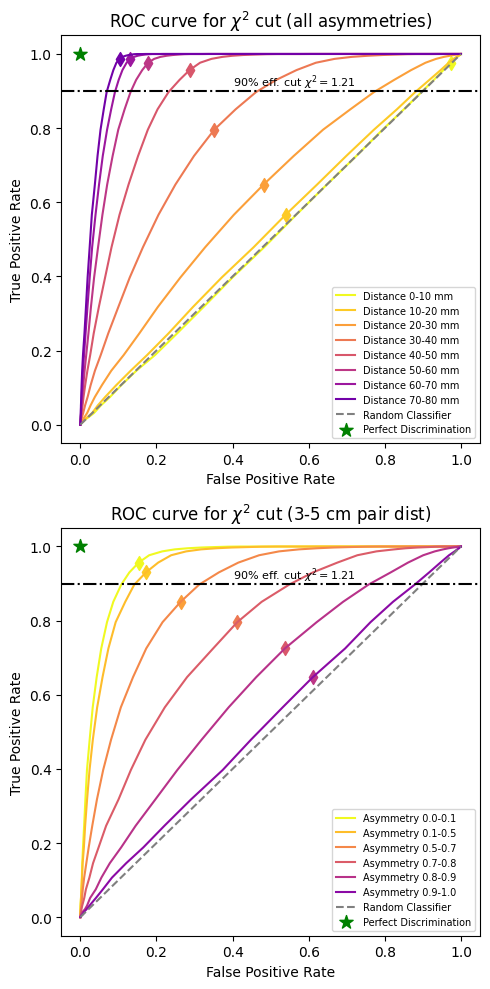

In [ ]:
import matplotlib.cm as cm

fig = plt.figure(figsize=(5, 10))

dists = np.concatenate([
    results[f'{asym}%']['dist'][results[f'{asym}%']['chi2'] < 10]
    for asym in np.arange(50, 100, 1)
])

asym = np.concatenate([
    results[f'{asym}%']['asym'][results[f'{asym}%']['chi2'] < 10]
    for asym in np.arange(50, 100, 1)
])

chi2_singles = data['chi2'][data['chi2'] < 10]
cut = np.percentile(chi2_singles, 90)
chi2_doubles = np.concatenate([
    results[f'{asym}%']['chi2'][results[f'{asym}%']['chi2'] < 10]
    for asym in np.arange(50, 100, 1)
])
all_chi2_values = np.concatenate([chi2_singles, chi2_doubles])
thresholds = np.logspace(np.log10(np.min(all_chi2_values)), np.log10(np.max(all_chi2_values)), 100)

ax = fig.add_subplot(211)
dist_ranges = [00, 10, 20, 30, 40, 50, 60, 70, 80]
for k, value in enumerate(dist_ranges[:-1]):
    mask = (dists >= dist_ranges[k]) & (dists < dist_ranges[k + 1])
    if np.any(mask):
        chi2_doubles_subset = chi2_doubles[mask]
        FPR_subset = []
        TPR_subset = []
        for thresh in thresholds:
            FPR_subset.append((chi2_doubles_subset < thresh).mean())
            TPR_subset.append((chi2_singles < thresh).mean())
        FPR_subset, TPR_subset = np.array(FPR_subset), np.array(TPR_subset)
        
        J = TPR_subset - FPR_subset
        optimal_idx = np.argmax(J)
        optimal_threshold = thresholds[optimal_idx]
        optimal_fpr = FPR_subset[optimal_idx]
        optimal_tpr = TPR_subset[optimal_idx]
        ax.scatter(optimal_fpr, optimal_tpr, color=cm.plasma_r(k / len(dist_ranges)), s=50, marker='d')#, label=fr'Optimal $ \chi^2 $ cut: {optimal_threshold:.2f} (FPR={optimal_fpr *100:.2f}%, TPR={optimal_tpr *100:.2f}%)')
        
        asym_bins = np.linspace(0, 1, 16)
        bin_centers = 0.5 * (asym_bins[1:] + asym_bins[:-1])
        chi2_medians = []
            
        for i in range(len(asym_bins)-1):
            mask = (asym > asym_bins[i]) & (asym < asym_bins[i+1])
            chi2_medians.append(np.median(chi2_doubles[mask]))
        medians = np.array(chi2_medians)
        discriminatory_asym = np.interp(optimal_threshold, medians, bin_centers)
        print(f"Discriminatory asymmetry for {value}-{dist_ranges[k + 1]} mm pair separation: {discriminatory_asym:.2f} at optimal chi2 threshold {optimal_threshold:.2f}")

        ax.plot(FPR_subset, TPR_subset, label=f'Distance {value}-{dist_ranges[k + 1]} mm', color=cm.plasma_r(k / len(dist_ranges)))
ax.plot([0, 1], [0, 1], ls='--', color='gray', label='Random Classifier')
ax.axhline(0.9, ls='-.', color='black')
ax.text(0.4, 0.9, f'90% eff. cut $\chi^2 = {cut:.2f} $', color='black', fontsize=8, ha='left', va='bottom')
ax.scatter(0, 1, color='green', marker='*', s=100, label='Perfect Discrimination')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(fr'ROC curve for $\chi^2$ cut (all asymmetries)')
ax.legend(fontsize=7)

ax = fig.add_subplot(212)
asym_ranges = [0.0, 0.1, 0.5, 0.7, 0.8, 0.9, 1.0]
for k, value in enumerate(asym_ranges[:-1]):
    mask_dist = (dists >= 30) & (dists <= 50)
    mask = (asym >= asym_ranges[k]) & (asym < asym_ranges[k + 1]) & mask_dist
    if np.any(mask):
        chi2_doubles_subset = chi2_doubles[mask]
        FPR_subset = []
        TPR_subset = []
        for thresh in thresholds:
            FPR_subset.append((chi2_doubles_subset < thresh).mean())
            TPR_subset.append((chi2_singles < thresh).mean())
        FPR_subset, TPR_subset = np.array(FPR_subset), np.array(TPR_subset)

        J = TPR_subset - FPR_subset
        optimal_idx = np.argmax(J)
        optimal_threshold = thresholds[optimal_idx]
        optimal_fpr = FPR_subset[optimal_idx]
        optimal_tpr = TPR_subset[optimal_idx]
        ax.scatter(optimal_fpr, optimal_tpr, color=cm.plasma_r(k / len(dist_ranges)), s=50, marker='d')#, label=fr'Optimal $ \chi^2 $ cut: {optimal_threshold:.2f} (FPR={optimal_fpr *100:.2f}%, TPR={optimal_tpr *100:.2f}%)')
        
        dist_bins = np.linspace(0, 100, 36)
        bin_centers = 0.5 * (dist_bins[1:] + dist_bins[:-1])
        chi2_medians = []
            
        for i in range(len(dist_bins)-1):
            mask = (dists > dist_bins[i]) & (dists < dist_bins[i+1])
            chi2_medians.append(np.median(chi2_doubles[mask]))
        medians = np.array(chi2_medians)
        
        discriminatory_distance = np.interp(optimal_threshold, medians, bin_centers)
        print(f"Discriminatory distance for {value}-{asym_ranges[k + 1]} asymmetry: {discriminatory_distance:.2f} mm at optimal chi2 threshold {optimal_threshold:.2f}")

        ax.plot(FPR_subset, TPR_subset, label=f'Asymmetry {value}-{asym_ranges[k + 1]}', color=cm.plasma_r(k / len(asym_ranges)))
ax.plot([0, 1], [0, 1], ls='--', color='gray', label='Random Classifier')
ax.axhline(0.9, ls='-.', color='black')
ax.text(0.4, 0.9, f'90% eff. cut $\chi^2 = {cut:.2f} $', color='black', fontsize=8, ha='left', va='bottom')
ax.scatter(0, 1, color='green', marker='*', s=100, label='Perfect Discrimination')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(fr'ROC curve for $\chi^2$ cut (3-5 cm pair dist)')
ax.legend(fontsize=7)      

plt.tight_layout()

In [3]:
# import matplotlib.cm as cm
# fig, axes = plt.subplots(1, 2, figsize=(18,8))

# for asym, ax in zip([60, 90], axes):
#     # cc = (results[f'{asym}%']['chi2'] < 10)
#     dist_vals = results[f'{asym}%']['dist']
#     chi2_vals = results[f'{asym}%']['chi2']

#     chi2_bins = np.linspace(0, 1.8, 76)
#     signal_efficiency = []

#     for i in range(len(chi2_bins)-1):
#         mask = (chi2_values < chi2_bins[i+1])
#         signal_efficiency.append(mask.sum()/chi2_values.sum())
#     signal_efficiency = np.array(signal_efficiency)

#     color1 = 'tab:blue'
#     ax.plot(chi2_bins[:-1], signal_efficiency, color=color1, lw=8, alpha=0.5)
#     ax.set_xlabel('$\chi^2$ cut')
#     ax.set_ylabel('Single Scatter Signal Efficiency', color=color1)
#     ax.tick_params(axis='y', labelcolor=color1)
#     ax.set_ylim(-0.05, 1.05)

#     axhline = ax.axhline(0.9, ls='--', color='black', lw=1)
#     ax.text(0.75, 0.92, '90% signal efficiency', color='black', fontsize=10, ha='left', va='bottom')
#     # chi2_cut = np.percentile(chi2_values, 90)
#     # ax.axvline(chi2_cut, ls='--', color='black', lw=1, label=f'90% eff. cut: $\chi^2$={chi2_cut:.2f}')
#     chi2_cut = np.interp(0.9, signal_efficiency, chi2_bins[:-1])
#     ax.axvline(chi2_cut, ls='--', color='black', lw=1, label=f'90% eff. cut: $\chi^2$={chi2_cut:.2f}')

#     ax2 = ax.twinx()
#     color2 = 'tab:red'
#     ax2.set_ylabel('Multiple Scatter Contamination Fraction', color=color2)
#     ax2.tick_params(axis='y', labelcolor=color2)

#     dist_ranges = [0, 10, 20, 30, 40, 50]
#     for k, value in enumerate(dist_ranges):
#         color = cm.plasma_r(k/6)
#         mm = (dist_vals < value + 10) & (dist_vals > value)
#         ms_chi2 = chi2_vals[mm]
#         contamination = []

#         for i in range(len(chi2_bins)-1):
#             mask = (ms_chi2 < chi2_bins[i+1])
#             contamination.append(mask.sum()/len(ms_chi2))
# # 
#         contamination = np.array(contamination)
#         ax2.plot(chi2_bins[:-1], contamination, color=color, ls='--', label=f'{value} < d < {value+10} mm')

#     full_contamination = []
#     for i in range(len(chi2_bins)-1):
#         full_mask = (chi2_vals < chi2_bins[i+1])
#         full_contamination.append(full_mask.sum()/len(chi2_vals))
#     full_contamination = np.array(full_contamination)
#     ax2.plot(chi2_bins[:-1], full_contamination, color=color2, ls='-', lw=3, label=f'Full MS sample')
#     ms_90 = np.interp(chi2_cut, chi2_bins[:-1], full_contamination)
#     ax2.axhline(ms_90, ls='--', color='black', lw=1)#, label=f'90% eff. cut: MS contamination={ms_90:.2f}')
#     ax2.text(chi2_cut + 0.15, ms_90 + 0.02, f'MS contamination = {ms_90*100:.2f}%', color='black', fontsize=10, ha='left', va='bottom')

#     ax2.set_ylim(-0.05, 1.05)
#     ax.set_title(f'Asymmetry {asym}$\%$ - {100-asym}$\%$')
#     ax2.legend(loc='upper left', title='Multiple scatter contamination fraction')
# plt.tight_layout()
# plt.show()

## Study of Double Scatters

log10(Chi2) = 1.76e-07 * areaBot_s2sum + 0.0162 * pair_dist + -0.457


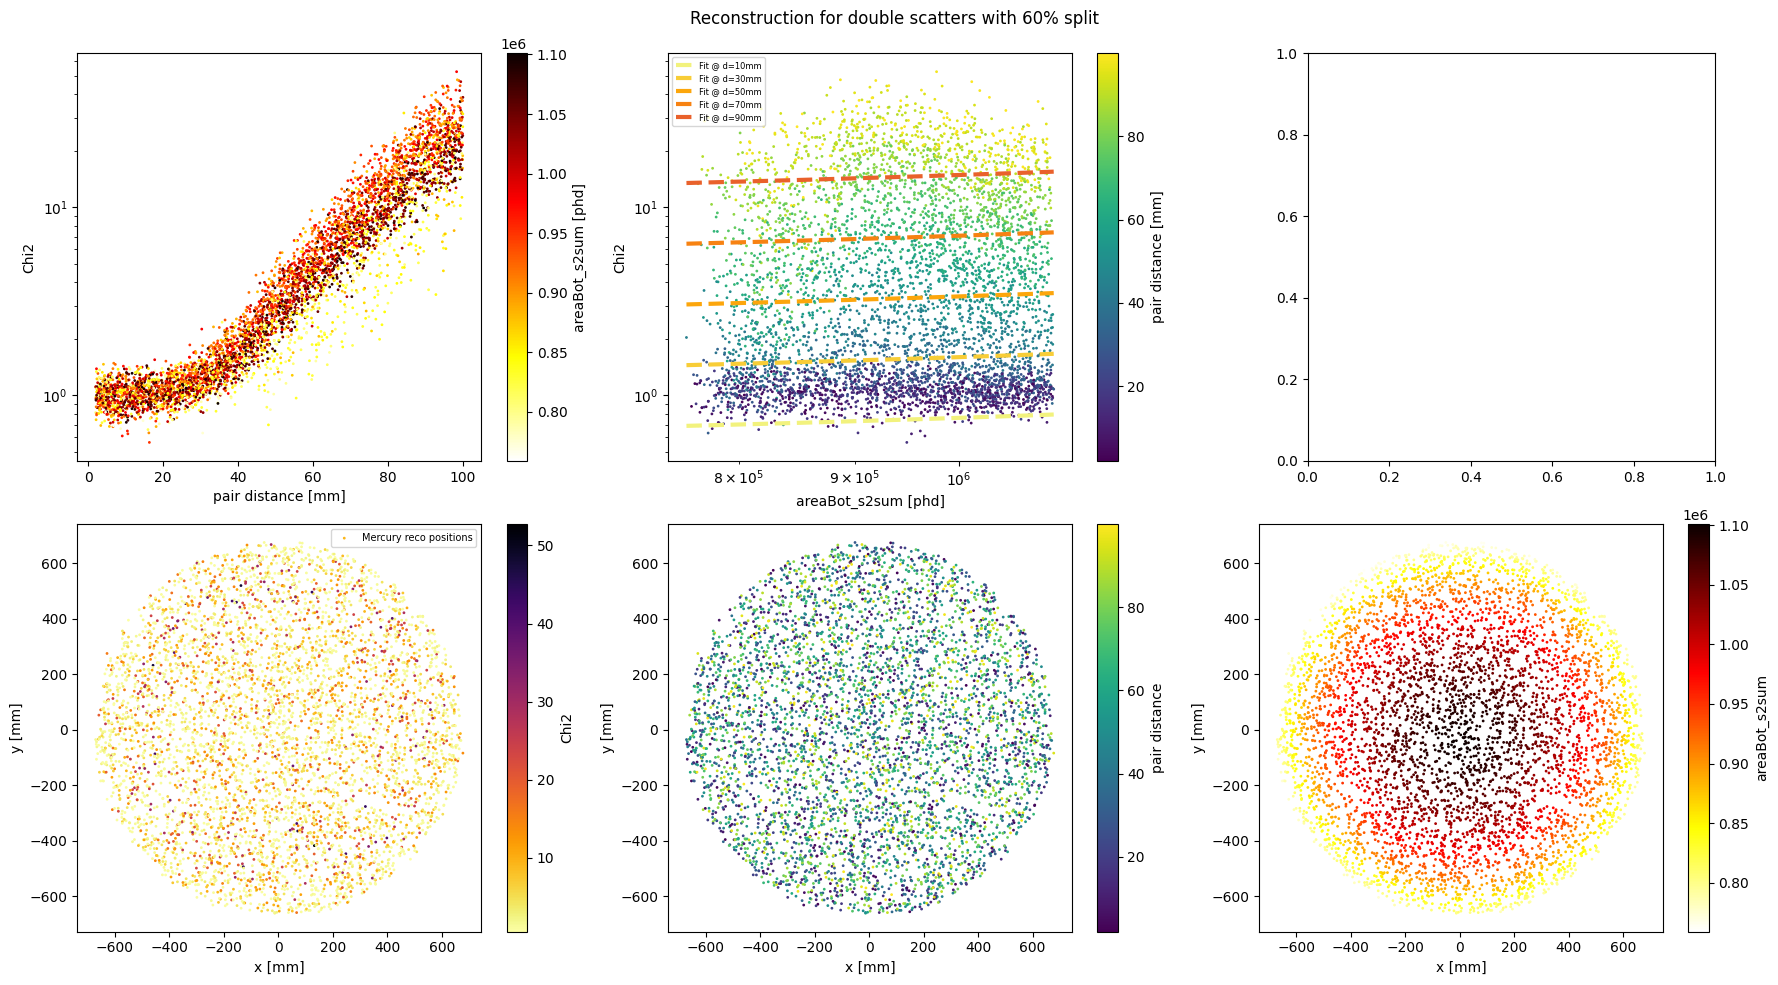

In [80]:
from numpy.linalg import lstsq
fig, ax = plt.subplots(2, 3, figsize=(18,10))

split_pct = 60
dists = results[f'{split_pct}%']['dist']
chi2_vals = results[f'{split_pct}%']['chi2']
x_reco = results[f'{split_pct}%']['xs_reco']
y_reco = results[f'{split_pct}%']['ys_reco']
areaBot_s2sum = results[f'{split_pct}%']['areaBot_s2sum']

cc = (results[f'{split_pct}%']['chi2'] < 100)


### Plot 00
scat1 = ax[0,0].scatter(dists[cc], chi2_vals[cc], s=1, 
                   c=areaBot_s2sum[cc], cmap='hot_r')
cbar=plt.colorbar(scat1, ax=ax[0,0])
cbar.set_label('areaBot_s2sum [phd]')

ax[0,0].set_xlabel('pair distance [mm]')
ax[0,0].set_ylabel('Chi2')
ax[0,0].set_yscale('log')

### Plot 01
scat3 = ax[0,1].scatter(areaBot_s2sum[cc], chi2_vals[cc], s=1,
                      c=dists[cc], cmap='viridis')
cbar=plt.colorbar(scat3, ax=ax[0,1])
cbar.set_label('pair distance [mm]')

ax[0,1].set_xlabel('areaBot_s2sum [phd]')
ax[0,1].set_ylabel('Chi2')
ax[0,1].set_xscale('log')
ax[0,1].set_yscale('log')

# 2-variable regression
# Build the design matrix: [s2_asym, pair_distance, intercept]
x1 = areaBot_s2sum[cc]
x2 = dists[cc] 
y  = np.log10(chi2_vals[cc])

X = np.column_stack([x1, x2, np.ones(len(x1))])
coeffs, residuals_sum, rank, sv = lstsq(X, y, rcond=None)
m_area, m_dist, b = coeffs
print(f'log10(Chi2) = {m_area:.3g} * areaBot_s2sum + {m_dist:.3g} * pair_dist + {b:.3g}')

x_fit = np.linspace(x1.min(), x1.max(), 100)
# Pick a few representative pair-distance values spanning your color range
dist_values = [10, 30, 50, 70, 90]  # adjust to match your actual mm range
cmap = plt.cm.inferno_r
# norm = plt.Normalize(vmin=x2.min(), vmax=x2.max())

for d in dist_values:
    y_fit = 10**(m_area * x_fit + m_dist * d + b)
    ax[0,1].plot(x_fit, y_fit, ls='--', lw=3, color=cmap((d)), 
                 label=f'Fit @ d={d}mm')

ax[0,1].legend(fontsize=6)

### Plot 02
ax[0,2].set_box_aspect(1)
# scat4 = ax[0,2].scatter(abs(s2_asym[cc]), results_sat.chi2[cc], s=1,
#                         c=dists[cc], cmap='viridis')
# cbar=plt.colorbar(scat4, ax=ax[0,2])
# cbar.set_label('pair distance [mm]')
# ax[0,2].set_xlabel('S2 absolute asymmetry')
# ax[0,2].set_ylabel('Chi2')
# ax[0,2].set_yscale('log')

# # 2-variable regression
# # Build the design matrix: [s2_asym, pair_distance, intercept]
# x1 = abs(s2_asym[cc])
# x2 = dists[cc]
# y  = np.log10(results_sat.chi2[cc])

# X = np.column_stack([x1, x2, np.ones(len(x1))])
# coeffs, residuals_sum, rank, sv = lstsq(X, y, rcond=None)
# m_asym, m_dist, b = coeffs
# print(f'log10(Chi2) = {m_asym:.3g} * s2_asym + {m_dist:.3g} * pair_dist + {b:.3g}')

# x_fit = np.linspace(x1.min(), x1.max(), 100)
# # Pick a few representative pair-distance values spanning your color range
# dist_values = [10, 30, 50, 70, 90]  # adjust to match your actual mm range
# cmap = plt.cm.inferno_r
# # norm = plt.Normalize(vmin=x2.min(), vmax=x2.max())

# for d in dist_values:
#     y_fit = 10**(m_asym * x_fit + m_dist * d + b)
#     ax[0,2].plot(x_fit, y_fit, ls='--', lw='3', color=cmap((d)), 
#                  label=f'Fit @ d={d}mm')

# ax[0,2].legend(fontsize=6)

### Plot 10
# ax[1,0].scatter(lceSim.Xtop, lceSim.Ytop, color='lightgray', s=120, alpha=0.3)
scat2 = ax[1,0].scatter(x_reco[cc], y_reco[cc], s=1, 
                   c=chi2_vals[cc], cmap='inferno_r', label='Mercury reco positions')
cbar = plt.colorbar(scat2, ax=ax[1,0])
cbar.set_label('Chi2')

# for i in range(len(xs[cc])):
#     label = 'Double scatter pairs' if i==0 else ''
#     ax[1,0].plot((xs[cc])[i], (ys[cc])[i], linewidth=0.5, color='black', markeredgecolor='red', marker='.', markersize=1, label=label)

ax[1,0].set_xlabel('x [mm]')
ax[1,0].set_ylabel('y [mm]')
ax[1,0].legend(fontsize=7, loc='upper right')

### Plot 11
scat5 = ax[1,1].scatter(x_reco[cc], y_reco[cc], s=1,
                        c=dists[cc], cmap='viridis')
cbar = plt.colorbar(scat5, ax=ax[1,1])
cbar.set_label('pair distance')
ax[1,1].set_xlabel('x [mm]')
ax[1,1].set_ylabel('y [mm]')

### Plot 12
scat6 = ax[1,2].scatter(x_reco[cc], y_reco[cc], s=1,
                        c=areaBot_s2sum[cc], cmap='hot_r')
cbar = plt.colorbar(scat6, ax=ax[1,2])
cbar.set_label('areaBot_s2sum')
ax[1,2].set_xlabel('x [mm]')
ax[1,2].set_ylabel('y [mm]')

# scat6 = ax[1,2].scatter(xs[:, 1], ys[:, 1], s=1,
#                         c=areaBot_s2b, cmap='hot_r', alpha=0.3)
# cbar = plt.colorbar(scat6, ax=ax[1,2])
# cbar.set_label('areaBot_s2b')
# ax[1,2].set_xlabel('x [mm]')
# ax[1,2].set_ylabel('y [mm]')

plt.suptitle(f'Reconstruction for double scatters with {split_pct}% split')
plt.tight_layout()

dist_bins = np.linspace(0, 100, 6)  # e.g. 5 bins
for i in range(len(dist_bins)-1):
    mask = (dists >= dist_bins[i]) & (dists < dist_bins[i+1])
    if mask.sum() > 10:
        corr = np.corrcoef(areaBot_s2sum[mask], np.log10(chi2_vals[mask]))[0,1]
        # print(f'Distance [{dist_bins[i]:.0f}, {dist_bins[i+1]:.0f}) mm: '
            #   f'n={mask.sum()}, corr(area, log10 Chi2) = {corr:.3f}')

In [91]:
# x_reco = np.sort(x_reco)
print(np.sort(results['60%']['xs_reco']))

[-670.07612755 -667.87262966 -667.04703762 ...  668.20670605  670.10037993
  677.40160759]


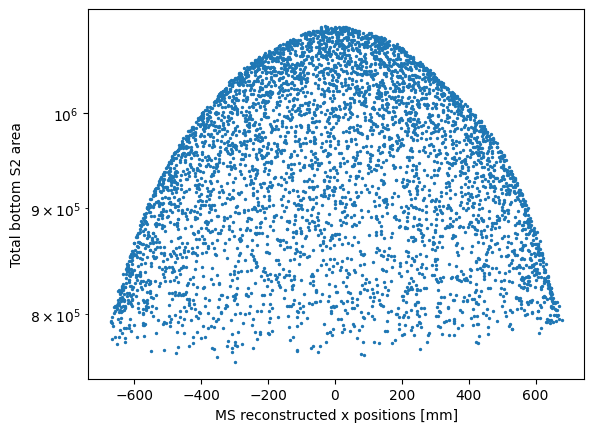

In [97]:
idx = np.argsort(results[f'{split_pct}%']['xs_reco'])
x_reco = results[f'{split_pct}%']['xs_reco'][idx]
areaBot_s2sum = results[f'{split_pct}%']['areaBot_s2sum'][idx]

plt.scatter(x_reco, areaBot_s2sum, s=2)
plt.xlabel('MS reconstructed x positions [mm]')
plt.ylabel('Total bottom S2 area')
plt.yscale('log')

## Generalisation to Multiple Scatters

### Synthetic MS

The contamination map is a conditional fraction given (extent, dominance). Sampling geometry non-uniformly doesn't bias it, as long as each bin is well populated. Reconstruction depends only on vertex positions and energy fractions, not on how the geometry was generated.

Ratio generator. A Dirichlet draw is symmetric and needs no rejection. A small concentration alpha gives one dominant vertex, and a large alpha gives near-equal shares. Drawing alpha log-uniformly spreads the dominance over the full range:

In [ ]:
from scipy.spatial.distance import pdist

def generate_compact_coordinates(n_scatters=2, max_radius=680, R_min=2, R_max=60,
                                 min_sep=2, max_attempts=1000):
    """n vertices uniform in a disk of radius R (R sampled uniformly), centred inside the detector.
    Max pairwise distance then spans ~R_min..2*R_max evenly, whatever n_scatters is."""
    # cluster centre, uniform over the detector disk
    rc = np.random.uniform(0, max_radius**2)**0.5
    tc = np.random.uniform(0, 2*np.pi)
    xc, yc = rc*np.cos(tc), rc*np.sin(tc)

    for _ in range(max_attempts):
        R = np.random.uniform(R_min, R_max)
        r = R * np.sqrt(np.random.uniform(0, 1, n_scatters))
        th = np.random.uniform(0, 2*np.pi, n_scatters)
        x, y = xc + r*np.cos(th), yc + r*np.sin(th)
        if np.all(np.hypot(x, y) <= max_radius):
            pts = np.column_stack([x, y])
            if n_scatters == 1 or pdist(pts).min() >= min_sep:
                d = np.hypot(np.diff(x), np.diff(y))
                return list(x), list(y), d
    raise RuntimeError("could not place points")

def generate_ratio(n_scatters):
    if n_scatters == 1:
        return np.array([1.0])
    d = np.random.uniform(1 / n_scatters, 1)          # dominance, uniform by construction
    if n_scatters == 2:
        return np.array([d, 1 - d])
    for _ in range(50):
        rest = (1 - d) * np.random.dirichlet(np.ones(n_scatters - 1))
        if rest.max() <= d:                            # keep d the true maximum
            break
    else:
        rest = np.full(n_scatters - 1, (1 - d) / (n_scatters - 1))   # near the lower edge: equal split
    return np.concatenate([[d], rest])

In [201]:
from scipy.spatial.distance import pdist

# Generate dataset with PMT response of n-scatter events
N = 100000                  # per multiplicity; there is no split_values loop any more, so this is cheaper overall
energy = 2457.83            # keV
n_scatters_values = [2, 3, 4, 5]

# Initialize mercury with the same LRFs as from the simulator
mercury = pywrapper_mercury.PyMercury()
mercury.setTopLRF(lceSim.getModel().getTopLRF())
mercury.makeMercury()

results = {}
for n_scatters in n_scatters_values:
    print(f"Generating {N} events with {n_scatters} scatters...")

    xx, yy, ratios, extents = [], [], [], []
    s2topDset, s2botDset = [], []
    n_failed = 0

    for i in range(N):
        try:
            xt, yt, _ = generate_compact_coordinates(n_scatters=n_scatters)
            ratio = generate_ratio(n_scatters)
            s2top, s2bot = lceSim.simScatter(xt, yt, energy, ratio=ratio)
        except (RuntimeError, ValueError):
            n_failed += 1
            continue

        s2topDset.append(s2top)
        s2botDset.append(s2bot)
        xx.append(xt)
        yy.append(yt)
        ratios.append(ratio)
        extents.append(pdist(np.column_stack([xt, yt])).max())

    # Apply saturation to top array, then reconstruct
    s2topDset_sat = lceSim.applyPMTResponseCurve(np.array(s2topDset))
    mercury.reconstruct(s2topDset_sat)
    mercury_reco = mercury.getResults()

    ratios = np.array(ratios)
    results[n_scatters] = {
        'xs': np.array(xx),                              # (N, n_scatters)
        'ys': np.array(yy),                              # (N, n_scatters)
        'ratio': ratios,                                 # (N, n_scatters) energy fractions
        'edep': ratios * energy / 1000,                  # (N, n_scatters) MeV
        'extent': np.array(extents),                     # (N,) max pairwise distance [mm]
        'dominance': ratios.max(axis=1),                 # (N,) largest energy fraction
        's2topDset': s2topDset_sat,                      # (N, 248)
        's2botDset': np.array(s2botDset),                # (N, 121)
        'chi2': np.array(mercury_reco.chi2).flatten(),   # (N,)
        'xs_reco': np.array(mercury_reco.x).flatten(),   # (N,)
        'ys_reco': np.array(mercury_reco.y).flatten(),   # (N,)
    }
    print(f"  kept {len(xx)} events, {n_failed} failed")

with open('results_new.pkl', 'wb') as f:
    pickle.dump(results, f)

Generating 100000 events with 2 scatters...


/opt/python/mercury/lib/python3.8/site-packages/lz_lce_sim/lce_sim.py:71: RuntimeWarning: divide by zero encountered in divide
  return B * np.tanh((x - x0) / (A - x0)) + x0


  kept 100000 events, 0 failed
Generating 100000 events with 3 scatters...
  kept 100000 events, 0 failed
Generating 100000 events with 4 scatters...
  kept 100000 events, 0 failed
Generating 100000 events with 5 scatters...
  kept 100000 events, 0 failed


In [202]:
extent_by_nscat, dominance_by_nscat, chi2s_by_nscat = {}, {}, {}
for n in n_scatters_values:
    r = results[n]
    ok = (r['chi2'] > 0) & (r['chi2'] < 10)
    extent_by_nscat[n]    = r['extent'][ok]
    dominance_by_nscat[n] = r['dominance'][ok]
    chi2s_by_nscat[n]     = r['chi2'][ok]

In [5]:
with open('results_new.pkl', 'rb') as file:
    results = pickle.load(file)

5156 / 100000 events match


/tmp/ipykernel_423188/277237613.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


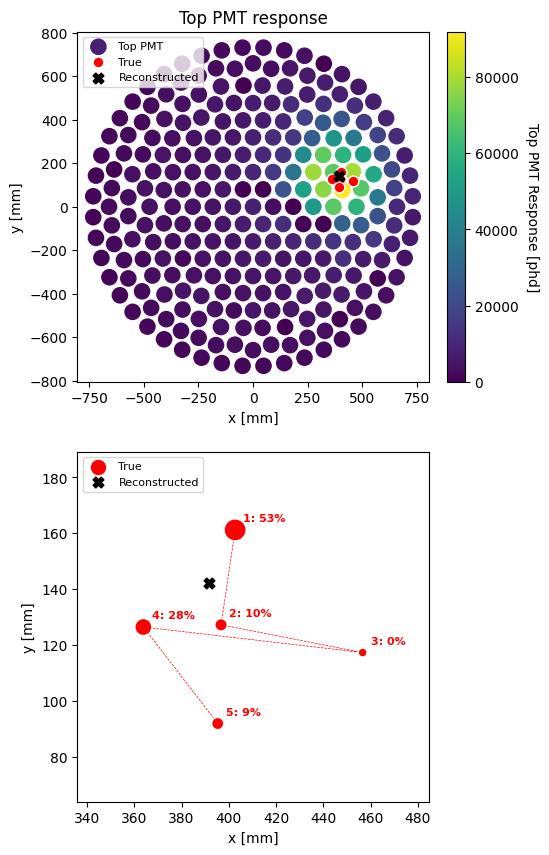

In [7]:
import matplotlib.gridspec as gridspec

n_scatters = 5
r = results[n_scatters]

# --- choose which kind of event to look at ---
min_sep_required = 90      # mm
require_all_pairs = False   # True: every pair > 90 mm; False: only the max pairwise distance (extent) > 90 mm
pick = 1                   # which of the matching events to show

valid = (r['chi2'] > 0) & (r['chi2'] < 10)

if require_all_pairs:
    min_pair = np.array([pdist(np.column_stack([x, y])).min() for x, y in zip(r['xs'], r['ys'])])
    far = min_pair > min_sep_required
else:
    far = r['extent'] > min_sep_required

idx = np.where(valid & far)[0]
print(f"{len(idx)} / {len(r['chi2'])} events match")
evtid = idx[pick]

xs, ys, ratio = r['xs'][evtid], r['ys'][evtid], r['ratio'][evtid]
x_reco, y_reco = r['xs_reco'][evtid], r['ys_reco'][evtid]
sizes = 40 + 400 * ratio                       # marker area follows energy fraction

def draw_true(ax, size=True, with_labels=True):
    if size:
        ax.scatter(xs, ys, s=sizes, c='red', edgecolor='white', zorder=3, label='True')
    else:
        ax.scatter(xs, ys, s=60, c='red', edgecolor='white', zorder=3, label='True')
    if with_labels:
        for i, (xi, yi, ri) in enumerate(zip(xs, ys, ratio)):
            ax.annotate(f"{i+1}: {ri*100:.0f}%", (xi, yi), textcoords='offset points',
                        xytext=(6, 6), fontsize=8, color='red', fontweight='bold')
    ax.scatter(x_reco, y_reco, s=60, c='black', marker='X', zorder=4, label='Reconstructed')

fig = plt.figure(figsize=(5, 10))
gs = gridspec.GridSpec(2, 2, width_ratios=[20, 1], height_ratios=[1, 1],
                        hspace=0.2, wspace=0.1)

ax0 = fig.add_subplot(gs[0, 0])
cax0 = fig.add_subplot(gs[0, 1])   # colorbar goes here, not squeezed from ax0
ax1 = fig.add_subplot(gs[1, 0])
# ax2 = fig.add_subplot(gs[2, 0])
# cax2 = fig.add_subplot(gs[2, 1])

scat = ax0.scatter(lceSim.Xtop, lceSim.Ytop, c=r['s2topDset'][evtid], s=120, label='Top PMT')
plt.colorbar(scat, cax=cax0, ax=ax0).set_label('Top PMT Response [phd]', rotation=270, labelpad=15)
draw_true(ax0, size=False, with_labels=False)
ax0.set(xlabel='x [mm]', ylabel='y [mm]', title='Top PMT response')
ax0.legend(fontsize=8, loc='upper left')

# scat = ax2.scatter(lceSim.Xbot, lceSim.Ybot, c=r['s2botDset'][evtid], s=120)
# plt.colorbar(scat, cax=cax2, ax=ax2).set_label('Bottom PMT Response [phd]', rotation=270, labelpad=15)
# draw_true(ax2, size=True, with_labels=False)
# ax2.set(xlabel='x [mm]', ylabel='y [mm]', title='Bottom PMT response')
# ax2.legend()

draw_true(ax1, size=True, with_labels=True)
ax1.plot(xs, ys, ls='--', lw=0.5, color='red', zorder=2)
pad = 0.3 * max(r['extent'][evtid], 10)
allx, ally = np.append(xs, x_reco), np.append(ys, y_reco)
ax1.set(xlim=(allx.min() - pad, allx.max() + pad), ylim=(ally.min() - pad, ally.max() + pad),
       xlabel='x [mm]', ylabel='y [mm]')#, title='Zoom: true vertices (label: n, energy share)')
ax1.legend(fontsize=8, loc='upper left')

# plt.suptitle(
#     fr"{n_scatters}-scatter evt: extent = {r['extent'][evtid]:.1f} mm, "
#     fr"dominance = {r['dominance'][evtid]:.2f}, "
#     fr"shares = {np.array2string(ratio, precision=2)}, "
#     fr"$\chi^2$ = {r['chi2'][evtid]:.2f}"
# )
plt.tight_layout()

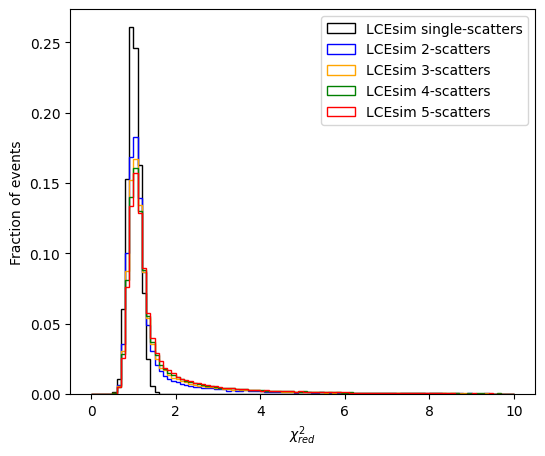

In [235]:
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

shared_range = (0, 10)
shared_bins  = 100
colors = ['blue', 'orange', 'green', 'red']  # extend if you add more n_scatters

with open('lceSim_SingleScatters.pkl', "rb") as file:
    data = pickle.load(file)

chi2_values = data['chi2'][data['chi2'] < 10]
ax.hist(chi2_values, bins=shared_bins, range= shared_range, histtype='step', color='black', 
        weights=np.ones_like(chi2_values) / len(chi2_values),
        # density=True,
        label='LCEsim single-scatters')

for i, n_scatters in enumerate(n_scatters_values):
    chi2 = chi2s_by_nscat[n_scatters]
    ax.hist(chi2, bins=shared_bins, range=shared_range, histtype='step',
            #  color=cm.viridis(i / len(n_scatters_values)),
            color=colors[i],
            weights=np.ones_like(chi2) / len(chi2),
            label=f'LCEsim {n_scatters}-scatters')
ax.set_xlabel(r'$\chi^2_{red}$')
ax.set_ylabel('Fraction of events')
ax.legend()
plt.show()

### Geant4 MS

In [10]:
df = pd.read_csv('/home/denis/lz_lce_sim/vertices_thread_newer100k.csv', header=None,
                 names=['event','x','y','z','edep','process','gammaID','photonCreator'])
# print(df.groupby('event').size().describe())        # vertices per event, should be lower than the ~4.8 before
print(df.groupby('event')['edep'].sum().max())      # should be <= ~2.6155 MeV
print(df['process'].value_counts())                 # expect compt, phot, conv

2.6155099999999996
process
compt      293777
phot       181543
conv        18065
unknown         5
Name: count, dtype: int64


In [216]:
# print(df.head(5))
# print(df.groupby('event')['process'].nunique().describe())
print(df['process'].unique())

['compt' 'phot' 'conv' 'unknown']


In [12]:
import glob
cols = ['event','x','y','z','edep','process','gammaID','photonCreator']
all_vertices = pd.concat(
    [pd.read_csv(f, header=None, names=cols) for f in glob.glob('/home/denis/lz_lce_sim/vertices_thread_newer100k.csv')],
    ignore_index=True)
# print(all_vertices['process'].value_counts())
# print(all_vertices.groupby('event').size().describe())
# print(all_vertices.groupby('event')['edep'].sum().max())   # still ~2.6155

max total: 2.615510 MeV, events above max+1 eV: 0
full absorption: 88.5%, single escape: 2.9%, double escape: 0.1%, everything else: 8.5%


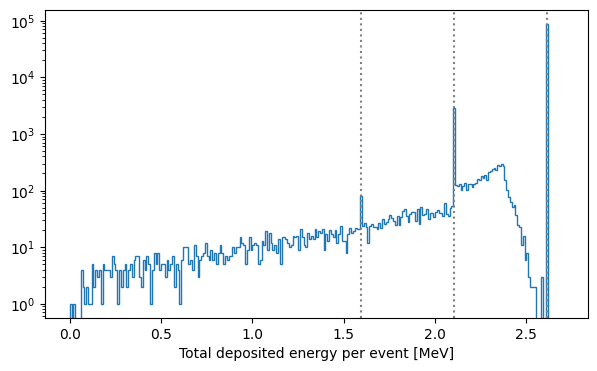

In [13]:
E0 = all_vertices.groupby('event')['edep'].sum().max()     # ≈ primary energy, MeV
tot = all_vertices.groupby('event')['edep'].sum()

print(f"max total: {E0:.6f} MeV, events above max+1 eV: {(tot > E0 + 1e-6).sum()}")

full   = np.isclose(tot, E0, atol=1e-3)                    # within 1 keV of the full energy
single = np.isclose(tot, E0 - 0.511, atol=5e-3)            # single-escape peak
double = np.isclose(tot, E0 - 1.022, atol=5e-3)            # double-escape peak
print(f"full absorption: {full.mean():.1%}, single escape: {single.mean():.1%}, "
      f"double escape: {double.mean():.1%}, everything else: {(~(full|single|double)).mean():.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tot, bins=np.linspace(0, 2.7, 271), histtype='step')
ax.set_yscale('log'); ax.set_xlabel('Total deposited energy per event [MeV]')
for e in (E0, E0 - 0.511, E0 - 1.022):
    ax.axvline(e, color='gray', ls=':')

#### Reconstructing events

In [223]:
# Build one entry per full gamma-ray event (not per pair), using ALL its vertices
event_records = []
n_failed = 0
n_skipped_resolvable = 0

for ev, group in all_vertices.groupby('event'):
    n_scat = len(group)
    if n_scat < 2:
        continue  # skip single-vertex events (fully absorbed on first interaction)

    z_vals = group['z'].values
    dz_max = z_vals.max() - z_vals.min()
    if dz_max >= 3.0:
        # generalizes your "dz < 3mm" cut: skip events resolvable in z
        n_skipped_resolvable += 1
        continue

    xg = group['x'].values
    yg = group['y'].values
    eg = group['edep'].values
    e_tot = eg.sum()
    ratio = eg / e_tot

    try:
        s2top, s2bot = lceSim.simScatter(list(xg), list(yg), energy=e_tot * 1000, ratio=ratio)
    except ValueError:
        n_failed += 1
        continue

    event_records.append({
        'event': ev,
        'n_scatters': n_scat,
        'xs': xg,
        'ys': yg,
        'edep': eg,
        'e_tot': e_tot,
        's2top': s2top,
        's2bot': s2bot,
        'dz_max': dz_max,
    })

print(f"{n_skipped_resolvable} events skipped (resolvable in z)")
print(f"{n_failed} events failed in LCE simulation and were skipped")
print(f"{len(event_records)} multi-scatter events retained for reconstruction")

90106 events skipped (resolvable in z)
62 events failed in LCE simulation and were skipped
7419 multi-scatter events retained for reconstruction


In [224]:
n_scatters_arr = np.array([r['n_scatters'] for r in event_records])
for n in sorted(np.unique(n_scatters_arr)):
    count = (n_scatters_arr == n).sum()
    print(f"n_scatters={n}: {count} events")

n_scatters=2: 3099 events
n_scatters=3: 2438 events
n_scatters=4: 1218 events
n_scatters=5: 471 events
n_scatters=6: 132 events
n_scatters=7: 48 events
n_scatters=8: 9 events
n_scatters=9: 4 events


Then reconstruct all retained events in one batch (regardless of multiplicity — mercury doesn't need to know how many true vertices produced the light pattern):

In [225]:
s2topDset = np.array([r['s2top'] for r in event_records])
s2botDset = np.array([r['s2bot'] for r in event_records])
n_scatters_arr = np.array([r['n_scatters'] for r in event_records])

# Apply saturation
s2topDset_sat = lceSim.applyPMTResponseCurve(s2topDset)

# Reconstruct
mercury = pywrapper_mercury.PyMercury()
mercury.setTopLRF(lceSim.getModel().getTopLRF())
mercury.makeMercury()
mercury.reconstruct(s2topDset_sat)
mercury_reco = mercury.getResults()

chi2s   = np.array(mercury_reco.chi2)
xs_reco = np.array(mercury_reco.x)
ys_reco = np.array(mercury_reco.y)

print(len(event_records), len(chi2s), len(n_scatters_arr))  # must all match now

/opt/python/mercury/lib/python3.8/site-packages/lz_lce_sim/lce_sim.py:71: RuntimeWarning: divide by zero encountered in divide
  return B * np.tanh((x - x0) / (A - x0)) + x0


7419 7419 7419


In [227]:
geant4_full = {
    'xs': [r['xs'] for r in event_records],       # ragged: variable length per event
    'ys': [r['ys'] for r in event_records],
    'edep': [r['edep'] for r in event_records],
    'n_scatters': n_scatters_arr,                  # (N,) — key addition
    's2topDset': s2topDset_sat,
    's2botDset': s2botDset,
    'chi2': chi2s,
    'xs_reco': xs_reco,
    'ys_reco': ys_reco,
}

with open('geant4_full_unresolvable_100k.pkl', "wb") as file:
    pickle.dump(geant4_full, file)

# e.g. chi2 distribution split by true multiplicity
for n in np.unique(n_scatters_arr):
    mask = n_scatters_arr == n
    print(f"n_scatters={n}: {mask.sum()} events, mean chi2 = {chi2s[mask].mean():.2f}, median={np.median(chi2s[mask]):.2f}")

n_scatters=2: 3099 events, mean chi2 = 692.93, median=1.02
n_scatters=3: 2438 events, mean chi2 = -10128907857916606051145742425834644937113600.00, median=1.02
n_scatters=4: 1218 events, mean chi2 = 791.87, median=1.03
n_scatters=5: 471 events, mean chi2 = 345.85, median=1.04
n_scatters=6: 132 events, mean chi2 = 312.76, median=1.02
n_scatters=7: 48 events, mean chi2 = 531.37, median=0.99
n_scatters=8: 9 events, mean chi2 = 4.78, median=1.19
n_scatters=9: 4 events, mean chi2 = 5.59, median=1.76


### Results Comparison

n_scatters=2: 98198/100000 kept (98.2%)
n_scatters=3: 98290/100000 kept (98.3%)
n_scatters=4: 98513/100000 kept (98.5%)
n_scatters=5: 98722/100000 kept (98.7%)
geant4 multiple-scatters: 7200/7419 kept (97.0%)


Text(0.5, 1.0, 'Reconstruction $\\chi^2$')

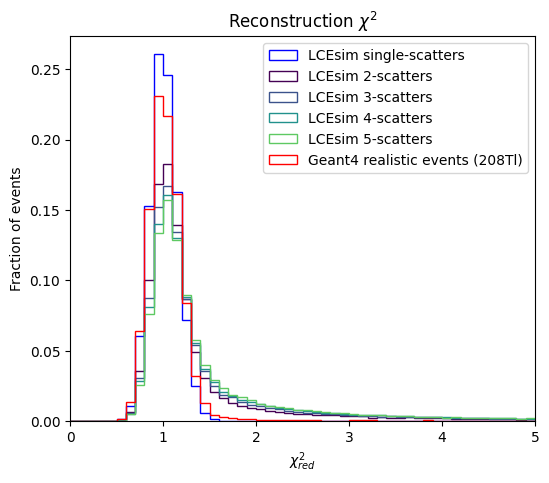

In [239]:
import matplotlib.cm as cm

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)

shared_range = (0, 10)
shared_bins  = 100

# --- single scatters ---
with open('lceSim_SingleScatters.pkl', "rb") as file:
    data = pickle.load(file)

chi2_values = data['chi2'][data['chi2'] < 10]
ax.hist(chi2_values, bins=shared_bins, range= shared_range, histtype='step', color='blue', 
        weights=np.ones_like(chi2_values) / len(chi2_values),
        # density=True,
        label='LCEsim single-scatters')

# --- synthetic multi-scatters (new results structure) ---
with open('results_new.pkl', 'rb') as file:
    results = pickle.load(file)

n_plot = [n for n in sorted(results.keys()) if n <= 5]      # cap at 5 scatters
chi2s_by_nscat = {}

for i, n_scatters in enumerate(n_plot):
    chi2 = results[n_scatters]['chi2']
    total = len(chi2)
    mask  = (chi2 > 0) & (chi2 < 10)
    chi2s_by_nscat[n_scatters] = chi2[mask]

    ax.hist(chi2[mask], bins=shared_bins, range=shared_range, histtype='step',
            color=cm.viridis(i / len(n_plot)),
            weights=np.ones_like(chi2[mask]) / len(chi2[mask]),
            label=f'LCEsim {n_scatters}-scatters')

    print(f"n_scatters={n_scatters}: {mask.sum()}/{total} kept ({100*mask.sum()/total:.1f}%)")

# --- Geant4 ---
with open('geant4_full_unresolvable_100k.pkl', 'rb') as file:
    geant4_full = pickle.load(file)

mask  = (geant4_full['chi2'] > 0) & (geant4_full['chi2'] < 10)
total = len(geant4_full['chi2'])
print(f"geant4 multiple-scatters: {mask.sum()}/{total} kept ({100*mask.sum()/total:.1f}%)")

g4_chi2s = geant4_full['chi2'][mask]
ax.hist(g4_chi2s, bins=shared_bins, range=shared_range, histtype='step', color='red',
        weights=np.ones_like(g4_chi2s) / len(g4_chi2s),
        label=f'Geant4 realistic events (208Tl)')

ax.set_xlabel(r'$\chi^2_{red}$')
ax.set_ylabel('Fraction of events')
ax.legend()
ax.set_xlim(0, 5)
ax.set_title('Reconstruction $\chi^2$')

In [230]:
from scipy.spatial.distance import pdist

def compute_extent_dominance(xs, ys, edep):
    """xs, ys, edep: arrays of shape (n_scatters,) for ONE event."""
    coords = np.column_stack([xs, ys])
    extent = pdist(coords).max() if len(xs) > 1 else 0.0
    dominance = edep.max() / edep.sum()
    return extent, dominance

# --- Synthetic side: already computed at generation time, just apply the chi2 filter ---
n_scatters_values = [n for n in sorted(results.keys()) if n <= 5]    # cap at 5
extent_by_nscat, dominance_by_nscat, chi2s_by_nscat = {}, {}, {}
for n in n_scatters_values:
    r = results[n]
    ok = (r['chi2'] > 0) & (r['chi2'] < 10)
    extent_by_nscat[n]    = r['extent'][ok]
    dominance_by_nscat[n] = r['dominance'][ok]
    chi2s_by_nscat[n]     = r['chi2'][ok]
    print(f"n_scatters={n}: {ok.sum()} / {len(ok)} events kept")

# --- Geant4 side, per event ---
g4_extent, g4_dominance, g4_nscat = [], [], []
for xs_i, ys_i, edep_i, nscat_i in zip(geant4_full['xs'], geant4_full['ys'],
                                         geant4_full['edep'], geant4_full['n_scatters']):
    e, d = compute_extent_dominance(np.asarray(xs_i), np.asarray(ys_i), np.asarray(edep_i))
    g4_extent.append(e)
    g4_dominance.append(d)
    g4_nscat.append(nscat_i)
g4_extent = np.array(g4_extent)
g4_dominance = np.array(g4_dominance)
g4_nscat = np.array(g4_nscat)

chi2s   = np.asarray(geant4_full['chi2'])
g4_etot = np.array([np.sum(e) for e in geant4_full['edep']])

assert len(g4_nscat) == len(g4_extent) == len(g4_dominance) == len(chi2s) == len(g4_etot)

n_scatters=2: 98198 / 100000 events kept
n_scatters=3: 98290 / 100000 events kept
n_scatters=4: 98513 / 100000 events kept
n_scatters=5: 98722 / 100000 events kept


In [231]:
from scipy.stats import binned_statistic_2d, gaussian_kde

def plot_contamination_map(x_synth, y_synth, chi2_synth,
                           chi2_single,
                           x_real, y_real, chi2_real, e_tot_real,
                           xlabel, ylabel, title_suffix,
                           nscat_real=None, max_nscat=5,               # <-- new: cap on the real side
                           x_range=(0, 70), y_range=(0.2, 1),         # <-- wider defaults
                           n_bins=(24, 20), min_count=20,              # <-- new: sparse-bin masking
                           target_eff=0.9, chi2_thresh=10,
                           e_range=(2.1, 2.7)):
    # Chi2 cut defined on the SINGLE-SCATTER distribution
    chi2_single_valid = chi2_single[(chi2_single > 0) & (chi2_single < chi2_thresh)]
    chi2_cut = np.quantile(chi2_single_valid, target_eff)

    dist_bins = np.linspace(*x_range, n_bins[0] + 1)
    asym_bins = np.linspace(*y_range, n_bins[1] + 1)

    # Contamination: fraction of multi-scatter events passing the single-scatter cut
    contamination_map, x_edge, y_edge, _ = binned_statistic_2d(
        x_synth, y_synth, chi2_synth,
        statistic=lambda x: np.mean(x < chi2_cut),
        bins=[dist_bins, asym_bins]
    )
    # Hide bins with too few synthetic events (a bin with 1 event can only read 0% or 100%)
    counts, _, _ = np.histogram2d(x_synth, y_synth, bins=[dist_bins, asym_bins])
    contamination_map = np.where(counts >= min_count, contamination_map, np.nan)

    x_centers = 0.5 * (x_edge[1:] + x_edge[:-1])
    y_centers = 0.5 * (y_edge[1:] + y_edge[:-1])
    X, Y = np.meshgrid(x_centers, y_centers)

    fig, ax = plt.subplots(figsize=(8, 6))
    cf = ax.contourf(X, Y, contamination_map.T, levels=np.linspace(0, 1, 51), cmap='coolwarm')
    plt.colorbar(cf, ax=ax, label='Expected contamination fraction')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(fr'Contamination map {title_suffix} '
                 fr'($\chi^2_{{cut}}={chi2_cut:.2f}$, {target_eff*100:.0f}% single-scatter eff.)')

    # ---- Geant4 population contours ----
    mask = ((chi2_real > 0) & (chi2_real < chi2_thresh) &
            (e_tot_real > e_range[0]) & (e_tot_real < e_range[1]))
    if nscat_real is not None:
        assert len(nscat_real) == len(x_real), "slice nscat_real like the other real arrays"
        mask &= (nscat_real <= max_nscat)                 # same multiplicity cap as the synthetic side

    gx_all, gy_all = x_real[mask], y_real[mask]
    in_view = ((gx_all >= x_range[0]) & (gx_all <= x_range[1]) &
               (gy_all >= y_range[0]) & (gy_all <= y_range[1]))
    gx, gy = gx_all[in_view], gy_all[in_view]             # KDE and percentile levels use visible events only

    print(f"{title_suffix}: {mask.sum()} / {len(x_real)} Geant4 events pass cuts, "
          f"{len(gx)} inside the window")
    if nscat_real is not None:
        ns, cnt = np.unique(nscat_real[mask], return_counts=True)
        print("    " + ", ".join(f"n={n}: {c}" for n, c in zip(ns, cnt)))

    if len(gx) > 10:
        kde = gaussian_kde(np.vstack([gx, gy]))
        Xg, Yg = np.meshgrid(np.linspace(*x_range, 200), np.linspace(*y_range, 200))
        density = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)
        density_at_points = kde(np.vstack([gx, gy]))
        levels = sorted([np.percentile(density_at_points, 100 - p) for p in [90, 75, 50]])

        cs = ax.contour(Xg, Yg, density, levels=levels, colors='black', linewidths=1.2)
        ax.clabel(cs, fmt={levels[0]: '90%', levels[1]: '75%', levels[2]: '50%'}, inline=True, fontsize=9)

    return fig, ax

(n_scatters=2): 2655 / 3099 Geant4 events pass cuts, 2642 inside the window
    n=2: 2655
(n_scatters=3): 2245 / 2438 Geant4 events pass cuts, 2222 inside the window
    n=3: 2245
(n_scatters=4): 1151 / 1218 Geant4 events pass cuts, 1131 inside the window
    n=4: 1151
(n_scatters=5): 447 / 471 Geant4 events pass cuts, 426 inside the window
    n=5: 447


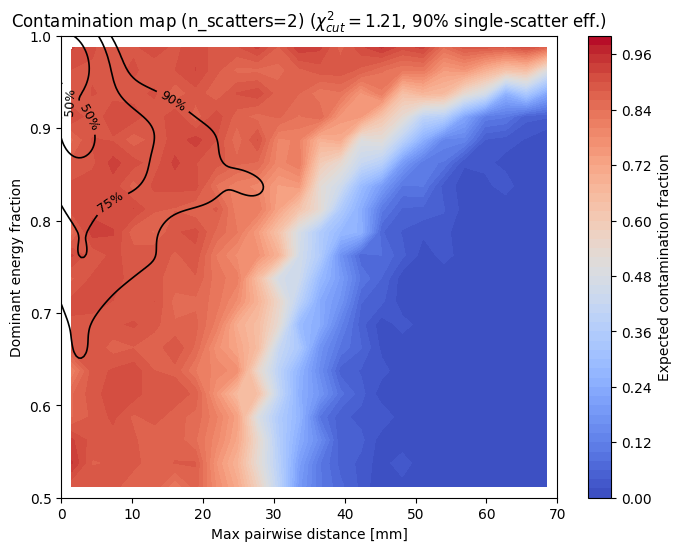

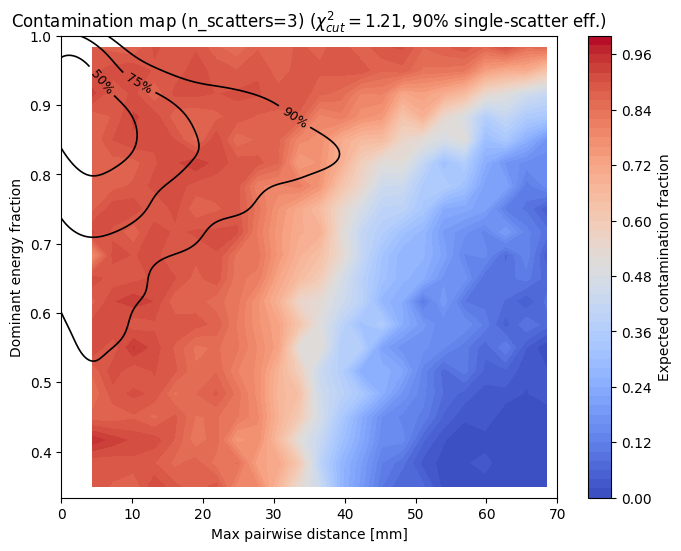

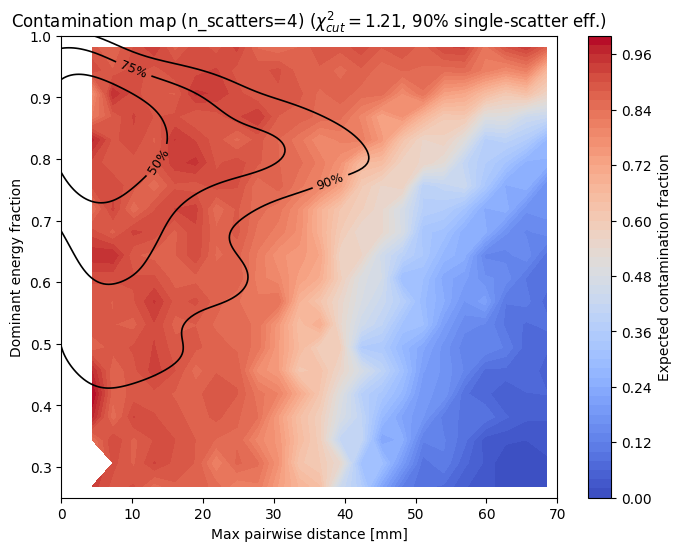

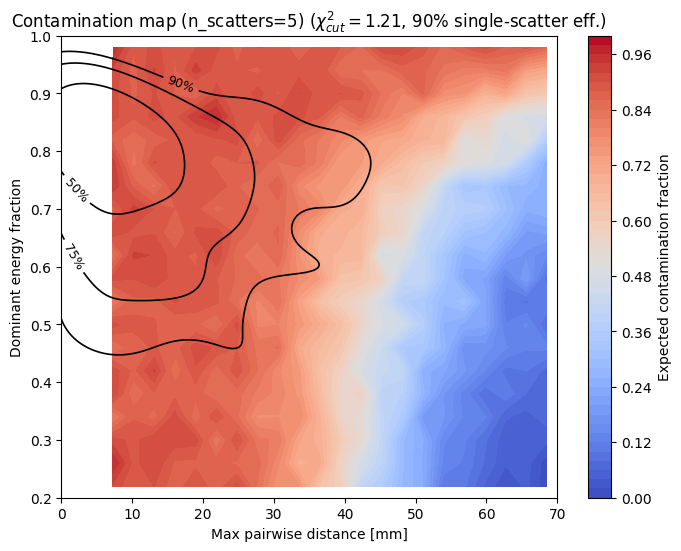

In [ ]:
with open('lceSim_SingleScatters.pkl', "rb") as file:
    data = pickle.load(file)

chi2_single_reco = data['chi2'][data['chi2'] < 10]

for n in n_scatters_values:
    m = g4_nscat == n
    if m.sum() < 10: continue
    plot_contamination_map(
        extent_by_nscat[n], dominance_by_nscat[n], chi2s_by_nscat[n],
        chi2_single_reco,
        g4_extent[m], g4_dominance[m], chi2s[m], g4_etot[m],
        xlabel='Max pairwise distance [mm]', ylabel='Dominant energy fraction',
        title_suffix=f'(n_scatters={n})',
        nscat_real=g4_nscat[m], y_range=(1/n, 1))

{2: 2655, 3: 2245, 4: 1151, 5: 447}


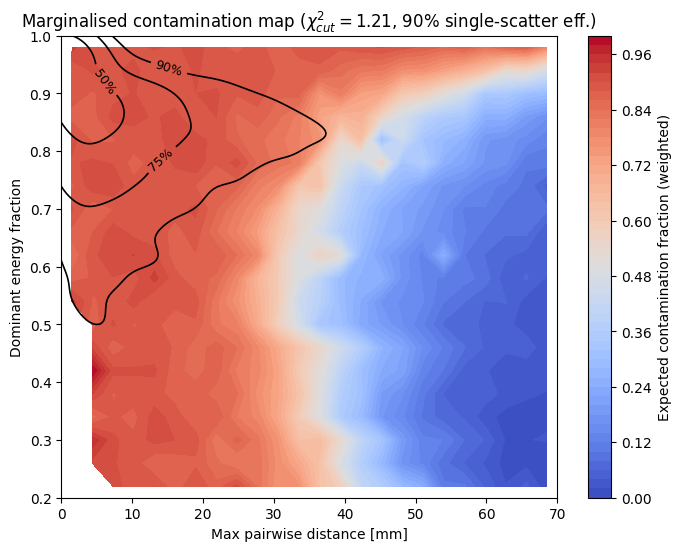

In [233]:
from scipy.stats import gaussian_kde

n_list    = [2, 3, 4, 5]
x_range   = (0, 70)
y_range   = (0.2, 1)
dist_bins = np.linspace(*x_range, 25)
dom_bins  = np.linspace(*y_range, 21)
min_count = 20      # min synthetic events per bin and multiplicity to trust f_n
min_real  = 5       # below this many real events in a bin, use the global multiplicity fractions
target_eff = 0.9

chi2_single_valid = chi2_single_reco[(chi2_single_reco > 0) & (chi2_single_reco < 10)]
chi2_cut = np.quantile(chi2_single_valid, target_eff)

real_mask = ((chi2s > 0) & (chi2s < 10) & (g4_etot > 2.1) & (g4_etot < 2.7)
             & np.isin(g4_nscat, n_list))
counts_g = {n: int((real_mask & (g4_nscat == n)).sum()) for n in n_list}
freq_g = {n: counts_g[n] / sum(counts_g.values()) for n in n_list}      # global real fractions
print(counts_g)

shape = (len(dist_bins) - 1, len(dom_bins) - 1)
f_all, ok_all, Nreal_all = {}, {}, {}
for n in n_list:
    ext, dom, c2 = extent_by_nscat[n], dominance_by_nscat[n], chi2s_by_nscat[n]
    N_syn,  _, _ = np.histogram2d(ext, dom, bins=[dist_bins, dom_bins])
    N_pass, _, _ = np.histogram2d(ext[c2 < chi2_cut], dom[c2 < chi2_cut], bins=[dist_bins, dom_bins])
    ok_all[n] = N_syn >= min_count
    with np.errstate(invalid='ignore', divide='ignore'):
        f_all[n] = np.where(ok_all[n], N_pass / N_syn, 0.0)
    m = real_mask & (g4_nscat == n)
    Nreal_all[n], _, _ = np.histogram2d(g4_extent[m], g4_dominance[m], bins=[dist_bins, dom_bins])

real_total = sum(Nreal_all.values())
fallback = real_total < min_real                 # bins with too few real events

num = np.zeros(shape); den = np.zeros(shape)
for n in n_list:
    w = np.where(fallback, freq_g[n], Nreal_all[n])       # local real counts, else global fractions
    w = np.where(ok_all[n], w, 0.0)                       # only multiplicities the synthetic sample covers here
    num += w * f_all[n]
    den += w

with np.errstate(invalid='ignore', divide='ignore'):
    contamination_map = np.where(den > 0, num / den, np.nan)

x_centers = 0.5 * (dist_bins[1:] + dist_bins[:-1])
y_centers = 0.5 * (dom_bins[1:] + dom_bins[:-1])
X, Y = np.meshgrid(x_centers, y_centers)

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(X, Y, contamination_map.T, levels=np.linspace(0, 1, 51), cmap='coolwarm')
plt.colorbar(cf, ax=ax, label='Expected contamination fraction (weighted)')

# hatch the bins that rely on the global-fraction fallback
# ax.contourf(X, Y, (fallback & ~np.isnan(contamination_map)).T.astype(float),
#             levels=[0.5, 1.5], colors='none', hatches=['///'])
# ax.text(0.02, 0.02, '// = few real events (global multiplicity weights)', transform=ax.transAxes, fontsize=7)

ax.set_xlabel('Max pairwise distance [mm]'); ax.set_ylabel('Dominant energy fraction')
ax.set_title(fr'Marginalised contamination map ($\chi^2_{{cut}}={chi2_cut:.2f}$, {target_eff*100:.0f}% single-scatter eff.)')

# Geant4 contours (visible events only), unchanged from before
gx_all, gy_all = g4_extent[real_mask], g4_dominance[real_mask]
in_view = ((gx_all >= x_range[0]) & (gx_all <= x_range[1]) & (gy_all >= y_range[0]) & (gy_all <= y_range[1]))
gx, gy = gx_all[in_view], gy_all[in_view]
kde = gaussian_kde(np.vstack([gx, gy]))
Xg, Yg = np.meshgrid(np.linspace(*x_range, 200), np.linspace(*y_range, 200))
density = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)
levels = sorted([np.percentile(kde(np.vstack([gx, gy])), 100 - p) for p in [90, 75, 50]])
cs = ax.contour(Xg, Yg, density, levels=levels, colors='black', linewidths=1.2)
ax.clabel(cs, fmt={levels[0]: '90%', levels[1]: '75%', levels[2]: '50%'}, inline=True, fontsize=9)
plt.show()

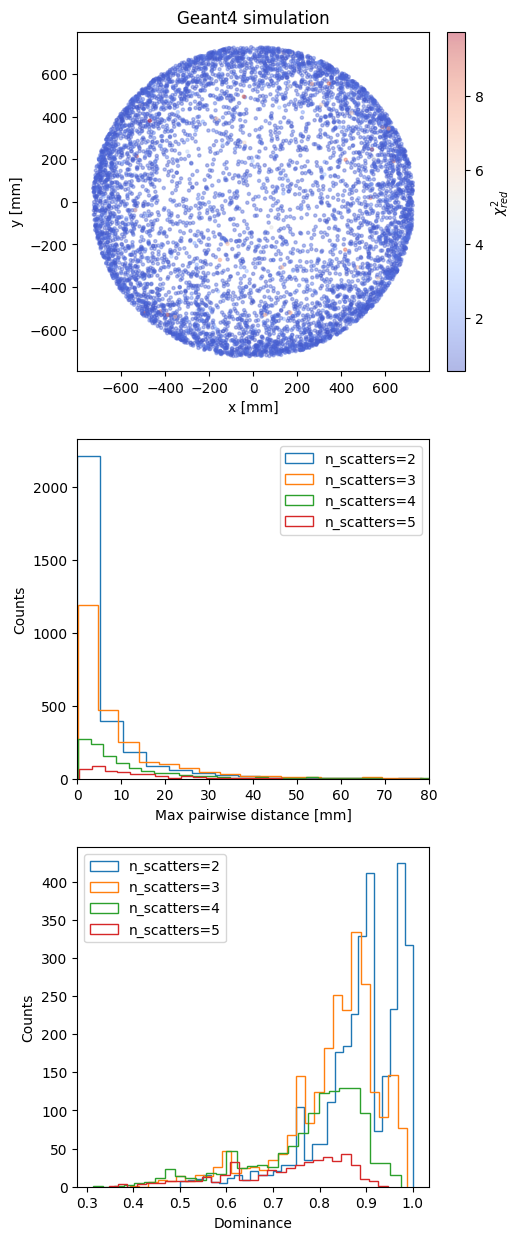

In [234]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(5, 15))
gs = gridspec.GridSpec(3, 2, width_ratios=[20, 1], height_ratios=[1, 1, 1],
                        hspace=0.2, wspace=0.1)

ax0 = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])   # colorbar goes here, not squeezed from ax0
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[2, 0])

mask = ((chi2s > 0) & (chi2s < 10) & (g4_etot > 2.1) & (g4_etot < 2.7))
scat = ax0.scatter(geant4_full['xs_reco'][mask], geant4_full['ys_reco'][mask], s=5, alpha=0.4,
                  c = geant4_full['chi2'][mask], cmap='coolwarm', label='Mercury reconstructed position')
fig.colorbar(scat, cax=cax, label=r'$\chi^2_{red}$')

# n_scatter = 2
# scat = ax0.scatter(extent_by_nscat[n_scatter], chi2s_by_nscat[n_scatter], s=3, alpha=0.5,
#                    c = dominance_by_nscat[n_scatter], cmap='coolwarm', label=f'{n_scatter}-scatters')
# fig.colorbar(scat, cax=cax, ax=ax0, label='Dominance')
# ax0.set(xlabel="Max pairwise distance [mm]", ylabel=r"$\chi^2_{red}$")

ax0.set_xlabel('x [mm]')
ax0.set_ylabel('y [mm]')
ax0.set_title(r'Geant4 simulation')

# ax0.set_xlabel('Max pairwise distance [mm]')
# ax0.set_ylabel(r"$\chi^2_{red}$")
# ax0.set_xlim(0, 70)
# ax0.set_title('LCEsim synthetic dataset')
# ax0.legend(loc='upper left')

for n_scatters in n_scatters_values:
    # ax1.hist(extent_by_nscat[n_scatters], bins=30, histtype='step', density=False,
    #         # weights=np.ones_like(extent_by_nscat[n_scatters]) / len(extent_by_nscat[n_scatters]),
    #         label=f'n_scatters={n_scatters}')
    ax1.hist(g4_extent[g4_nscat==n_scatters], bins=75, histtype='step', density=False,
                # weights=np.ones_like(g4_extent[g4_nscat==n_scatters]) / len(g4_extent[g4_nscat==n_scatters]),
                label=f'n_scatters={n_scatters}')

ax1.set_xlabel('Max pairwise distance [mm]')
ax1.set_ylabel('Counts')
ax1.set_xlim(0, 80)
# ax1.set_title('LCEsim synthetic dataset')
ax1.legend()

for n_scatters in n_scatters_values:
    # ax2.hist(dominance_by_nscat[n_scatters], bins=30, histtype='step', density=False,
    #         # weights=np.ones_like(dominance_by_nscat[n_scatters]) / len(dominance_by_nscat[n_scatters]),
    #         label=f'n_scatters={n_scatters}')
    ax2.hist(g4_dominance[g4_nscat==n_scatters], bins=30, histtype='step', density=False,
                    # weights=np.ones_like(g4_dominance[g4_nscat==n_scatters]) / len(g4_dominance[g4_nscat==n_scatters]),
                    label=f'n_scatters={n_scatters}')
ax2.set_xlabel('Dominance')
ax2.set_ylabel('Counts')

ax2.legend()

n_scatters_values: [2, 3, 4, 5]


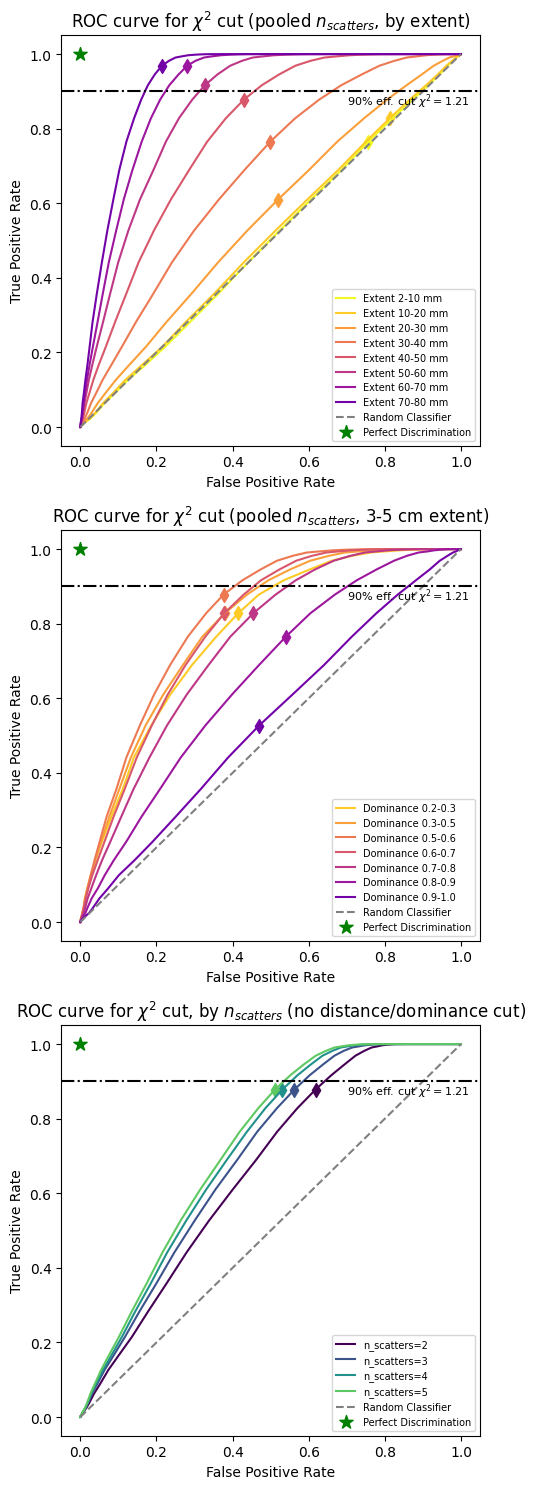

In [211]:
# 1. Cap n_scatters_values once
n_scatters_values = [n for n in n_scatters_values if n <= 5]
print("n_scatters_values:", n_scatters_values)

# 2. Full three-panel figure
import matplotlib.cm as cm

fig = plt.figure(figsize=(5, 15))

# --- Equal-N pool across all n_scatters (no real-occurrence weighting) ---
dists = np.concatenate([extent_by_nscat[n] for n in n_scatters_values])
asym  = np.concatenate([dominance_by_nscat[n] for n in n_scatters_values])
chi2_doubles = np.concatenate([chi2s_by_nscat[n] for n in n_scatters_values])

chi2_singles = chi2_single_reco[(chi2_single_reco > 0) & (chi2_single_reco < 10)]
cut = np.percentile(chi2_singles, 90)

all_chi2_values = np.concatenate([chi2_singles, chi2_doubles])
all_chi2_values = all_chi2_values[all_chi2_values > 0]
thresholds = np.logspace(np.log10(all_chi2_values.min()), np.log10(all_chi2_values.max()), 100)

def compute_roc(chi2_subset, chi2_singles, thresholds):
    FPR, TPR = [], []
    for thresh in thresholds:
        FPR.append((chi2_subset < thresh).mean())
        TPR.append((chi2_singles < thresh).mean())
    return np.array(FPR), np.array(TPR)

# ---------------- Panel 1: ROC by extent, pooled over n_scatters ----------------
ax = fig.add_subplot(311)
dist_ranges = [2, 10, 20, 30, 40, 50, 60, 70, 80]
for k, value in enumerate(dist_ranges[:-1]):
    mask = (dists >= dist_ranges[k]) & (dists < dist_ranges[k + 1])
    if np.any(mask):
        FPR_subset, TPR_subset = compute_roc(chi2_doubles[mask], chi2_singles, thresholds)
        J = TPR_subset - FPR_subset
        optimal_idx = np.argmax(J)
        ax.scatter(FPR_subset[optimal_idx], TPR_subset[optimal_idx],
                    color=cm.plasma_r(k / len(dist_ranges)), s=50, marker='d')
        ax.plot(FPR_subset, TPR_subset, label=f'Extent {value}-{dist_ranges[k + 1]} mm',
                 color=cm.plasma_r(k / len(dist_ranges)))

ax.plot([0, 1], [0, 1], ls='--', color='gray', label='Random Classifier')
ax.axhline(0.9, ls='-.', color='black')
ax.text(0.7, 0.9, fr'90% eff. cut $\chi^2 = {cut:.2f}$', color='black', fontsize=8, ha='left', va='top')
ax.scatter(0, 1, color='green', marker='*', s=100, label='Perfect Discrimination')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(r'ROC curve for $\chi^2$ cut (pooled $n_{scatters}$, by extent)')
ax.legend(fontsize=7)

# ---------------- Panel 2: ROC by dominance, pooled over n_scatters, 30-50mm extent ----------------
ax = fig.add_subplot(312)
asym_ranges = [0.1, 0.2, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for k, value in enumerate(asym_ranges[:-1]):
    mask_dist = (dists >= 30) & (dists <= 50)
    mask = (asym >= asym_ranges[k]) & (asym < asym_ranges[k + 1]) & mask_dist
    if np.any(mask):
        FPR_subset, TPR_subset = compute_roc(chi2_doubles[mask], chi2_singles, thresholds)
        J = TPR_subset - FPR_subset
        optimal_idx = np.argmax(J)
        ax.scatter(FPR_subset[optimal_idx], TPR_subset[optimal_idx],
                    color=cm.plasma_r(k / len(asym_ranges)), s=50, marker='d')
        ax.plot(FPR_subset, TPR_subset, label=f'Dominance {value}-{asym_ranges[k + 1]}',
                 color=cm.plasma_r(k / len(asym_ranges)))

ax.plot([0, 1], [0, 1], ls='--', color='gray', label='Random Classifier')
ax.axhline(0.9, ls='-.', color='black')
ax.text(0.7, 0.9, fr'90% eff. cut $\chi^2 = {cut:.2f}$', color='black', fontsize=8, ha='left', va='top')
ax.scatter(0, 1, color='green', marker='*', s=100, label='Perfect Discrimination')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(r'ROC curve for $\chi^2$ cut (pooled $n_{scatters}$, 3-5 cm extent)')
ax.legend(fontsize=7)

# ---------------- Panel 3: ROC by n_scatters ----------------
ax = fig.add_subplot(313)
for k, n_scatters in enumerate(n_scatters_values):
    chi2_n = chi2s_by_nscat[n_scatters]
    if len(chi2_n) == 0:
        continue
    FPR_subset, TPR_subset = compute_roc(chi2_n, chi2_singles, thresholds)
    J = TPR_subset - FPR_subset
    optimal_idx = np.argmax(J)
    ax.scatter(FPR_subset[optimal_idx], TPR_subset[optimal_idx],
                color=cm.viridis(k / len(n_scatters_values)), s=50, marker='d')
    ax.plot(FPR_subset, TPR_subset, label=f'n_scatters={n_scatters}',
             color=cm.viridis(k / len(n_scatters_values)))

ax.plot([0, 1], [0, 1], ls='--', color='gray', label='Random Classifier')
ax.axhline(0.9, ls='-.', color='black')
ax.text(0.7, 0.9, fr'90% eff. cut $\chi^2 = {cut:.2f}$', color='black', fontsize=8, ha='left', va='top')
ax.scatter(0, 1, color='green', marker='*', s=100, label='Perfect Discrimination')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(r'ROC curve for $\chi^2$ cut, by $n_{scatters}$ (no distance/dominance cut)')
ax.legend(fontsize=7)

plt.tight_layout()